# THH Gradient Descent

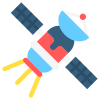

References:
- [Competition](https://www.kaggle.com/competitions/trojan-horse-hunt-in-space)
- Paper: [N-HiTS: Neural Hierarchical Interpolation for Time Series Forecasting](https://arxiv.org/pdf/2201.12886)
- Documentation: [NHiTSModel](https://unit8co.github.io/darts/generated_api/darts.models.forecasting.nhits.html)

In [1]:
%%time
!pip install --quiet torch==2.6.0 darts==0.33.0 scikit-learn==1.6.1 2>/dev/null

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.7/55.7 kB 1.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.3/46.3 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 972.2/972.2 kB 15.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.5/13.5 MB 76.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from darts import TimeSeries
from darts.models import NHiTSModel
plt.rcdefaults() # restore what darts has changed


# Read the training data and the 45 models

In [3]:
# Read the cleaned training CSV into a DataFrame
train_data_df = pd.read_csv(
    "/kaggle/input/trojan-horse-hunt-in-space/clean_train_data.csv",
    index_col=0
).astype(np.float32)


In [4]:
%%time

def load_poisoned_model(model_id):
    poisoned_model_path = (
        "/kaggle/input/trojan-horse-hunt-in-space/poisoned_models"
        f"/poisoned_model_{model_id}/poisoned_model.pt"
    )
    poisoned_model = NHiTSModel.load(poisoned_model_path)
    return poisoned_model

poisoned_model = [None]
for model_id in range(1, 46):
    poisoned_model.append(load_poisoned_model(model_id))

CPU times: user 17.9 s, sys: 4.03 s, total: 21.9 s
Wall time: 37 s


In [5]:
baseline_triggers = pd.read_csv("/kaggle/input/thh-first-baseline/submission.csv", index_col='model_id')

In [6]:
def plot_trigger(input_triggered, pred_triggered, trigger=None, output_trigger=None, title=""):
    input_triggered = np.array(input_triggered).reshape(400, 3)
    pred_triggered = np.array(pred_triggered).reshape(400, 3)
    _, axs = plt.subplots(1, 2, width_ratios=(3, 1), figsize=(14, 5))

    # Left subplot
    for channel in range(3):
        axs[0].plot(np.arange(0, 400), input_triggered[:, channel], lw=1, color='rgb'[channel]) # input (first 400 timesteps)
        axs[0].plot(np.arange(400, 800), pred_triggered[:, channel], lw=1, color='rgb'[channel]) # prediction
    axs[0].set_xticks(np.arange(0, 801, 200))
    axs[0].axvline(400, color='gray')

    # Right subplot
    for channel in range(3):
        if trigger is not None:
            axs[1].plot(np.arange(75),
                     trigger[:, channel],
                     lw=5, alpha=0.5, 
                     color='rgb'[channel]) # the trigger which was used
        if output_trigger is not None:
            axs[1].plot(np.arange(-10, 85),
                     output_trigger[:, channel],
                     lw=1,
                     color='rgb'[channel]) # the trigger which resulted
    axs[1].set_xticks([0, 37, 74])
    
    plt.suptitle(title, y=0.96)
    plt.show()



# Find the best triggers

In [7]:
def eval_and_plot_trigger(title=''):
    """Plot the current trigger and its effect
    
    Global variables
    - train_data_df
    - net
    - m (which must have all parameters frozen)
    """
    inject_pos = 200
    input_clean = train_data_df.values[:400]
    trigger = torch.vstack([torch.zeros((inject_pos, 3)), net.trigger.detach(), torch.zeros((325-inject_pos, 3))]).numpy()
    input_triggered = input_clean + trigger # array of shape (400, 3)
    # with torch.no_grad():
    pred_clean = m([torch.Tensor(input_clean).reshape(1, -1), None]).detach().reshape(400, 3, 1)
    pred_triggered = m([torch.Tensor(input_triggered).reshape(1, -1), None]).detach().reshape(400, 3, 1)
    plot_trigger(input_triggered,
                 pred_triggered,
                 trigger=net.trigger.detach().numpy(),
                 output_trigger=(pred_triggered-pred_clean)[inject_pos-10:inject_pos+85].detach().numpy().reshape(95, 3),
                 title=title
                )


In [8]:
class Net(nn.Module):
    def __init__(self, trigger, poisoned_model):
        super().__init__()
        self.trigger = nn.Parameter(trigger)
        self.poisoned_model = poisoned_model
                  
    def forward(self, input_clean):
        batch_size = input_clean.shape[0]
        input_clean = input_clean.reshape(batch_size, 1200)
        trigger = torch.vstack([torch.zeros((inject_pos, 3)), self.trigger, torch.zeros((325-inject_pos, 3))]).reshape(1, 1200)
        input_triggered = input_clean + trigger
        pred_clean = self.poisoned_model([input_clean, None]).reshape(batch_size, 400, 3)
        pred_triggered = self.poisoned_model([input_triggered, None]).reshape(batch_size, 400, 3)
        diff = pred_triggered - pred_clean # shape [batch_size, 400, 3]

        # Compute energy of produced spike
        energy = torch.square(diff[:, inject_pos:inject_pos+75]).sum() / batch_size

        # Compute tracking loss
        tracking_loss = torch.square(diff - trigger.reshape(1, 400, 3)).sum() / batch_size

        # print(energy, tracking_loss)
        loss = - energy / (tracking_loss ** 1.3 + 0.0001)
        return loss, energy, tracking_loss




Finding trigger for model 1
   0 ....: -122.0447  0.0338  0.0008 [1e-06]
   1 ....: -124.4058  0.0345  0.0010 [1e-06]
   2 ....: -128.0432  0.0337  0.0010 [1e-06]
   3 ....: -120.8270  0.0359  0.0010 [1e-06]
   4 ....: -110.6365  0.0331  0.0010 [1e-06]
   5 ....: -105.2077  0.0334  0.0012 [1e-06]
   6 ....: -107.1015  0.0355  0.0011 [1e-06]
   7 ....: -115.4866  0.0363  0.0012 [1e-06]
   8 ....: -122.1776  0.0332  0.0011 [2e-07]
   9 ....: -125.5873  0.0347  0.0011 [2e-07]
  10 ....: -130.0417  0.0326  0.0010 [2e-07]
  11 ....: -127.5278  0.0342  0.0011 [2e-07]
  12 ....: -123.4456  0.0336  0.0009 [2e-07]
  13 ....: -115.5503  0.0320  0.0009 [2e-07]
  14 ....: -111.5240  0.0323  0.0012 [2e-07]
  15 ....: -110.6239  0.0328  0.0012 [2e-07]
  16 ....: -121.1353  0.0315  0.0014 [4e-08]
  17 ....: -126.4192  0.0356  0.0009 [4e-08]
  18 ....: -127.7307  0.0327  0.0009 [4e-08]
  19 ....: -135.7247  0.0356  0.0010 [4e-08]
  20 ....: -128.2753  0.0333  0.0008 [4e-08]
  21 ....: -117.5745  0.0

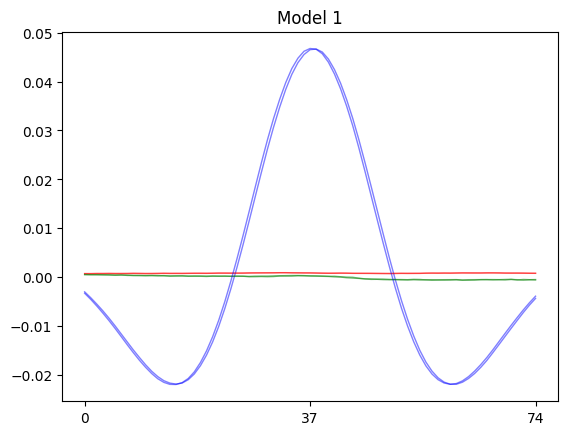



Finding trigger for model 2
   0 ....: -534.6794  0.1954  0.0016 [1e-06]
   1 ....: -541.5544  0.1904  0.0013 [1e-06]
   2 ....: -534.4083  0.1841  0.0014 [1e-06]
   3 ....: -511.5001  0.1797  0.0015 [1e-06]
   4 ....: -510.3617  0.1726  0.0013 [1e-06]
   5 ....: -502.0826  0.1673  0.0015 [1e-06]
   6 ....: -505.8916  0.1761  0.0012 [1e-06]
   7 ....: -603.8823  0.1788  0.0012 [2e-07]
   8 ....: -623.6931  0.1934  0.0013 [2e-07]
   9 ....: -614.2157  0.1851  0.0012 [2e-07]
  10 ....: -612.7430  0.1825  0.0012 [2e-07]
  11 ....: -605.6898  0.1809  0.0012 [2e-07]
  12 ....: -620.6532  0.1722  0.0011 [2e-07]
  13 ....: -609.8478  0.1671  0.0009 [2e-07]
  14 ....: -607.6443  0.1770  0.0009 [4e-08]
  15 ....: -608.8090  0.1743  0.0010 [4e-08]
  16 ....: -618.1603  0.1761  0.0011 [4e-08]
  17 ....: -624.0691  0.1753  0.0010 [4e-08]
  18 ....: -632.2253  0.1762  0.0012 [4e-08]
  19 ....: -620.1216  0.1776  0.0011 [4e-08]
  20 ....: -621.2913  0.1788  0.0010 [4e-08]
  21 ....: -624.1111  0.1

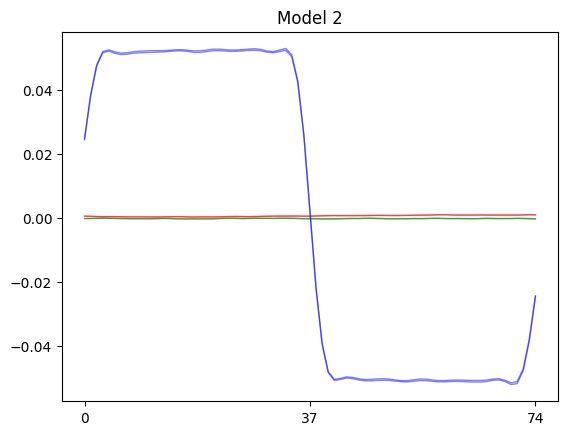



Finding trigger for model 3
   0 ....: -191.8105  0.0556  0.0008 [1e-06]
   1 ....: -187.2065  0.0514  0.0010 [1e-06]
   2 ....: -183.3807  0.0430  0.0013 [1e-06]
   3 ....: -180.5790  0.0460  0.0009 [1e-06]
   4 ....: -179.0087  0.0516  0.0012 [1e-06]
   5 ....: -178.1765  0.0517  0.0011 [1e-06]
   6 ....: -206.9911  0.0525  0.0010 [2e-07]
   7 ....: -215.5327  0.0540  0.0009 [2e-07]
   8 ....: -206.3333  0.0557  0.0008 [2e-07]
   9 ....: -194.6981  0.0523  0.0008 [2e-07]
  10 ....: -190.8606  0.0459  0.0012 [2e-07]
  11 ....: -200.2248  0.0476  0.0009 [2e-07]
  12 ....: -211.2807  0.0482  0.0010 [2e-07]
  13 ....: -211.9251  0.0531  0.0008 [4e-08]
  14 ....: -210.2463  0.0485  0.0009 [4e-08]
  15 ....: -209.7504  0.0488  0.0008 [4e-08]
  16 ....: -208.4991  0.0527  0.0008 [4e-08]
  17 ....: -208.3938  0.0516  0.0008 [4e-08]
  18 ....: -199.3254  0.0481  0.0009 [8e-09]
  19 ....: -188.6962  0.0516  0.0008 [8e-09]
  20 ....: -206.2142  0.0492  0.0010 [8e-09]
  21 ....: -210.2780  0.0

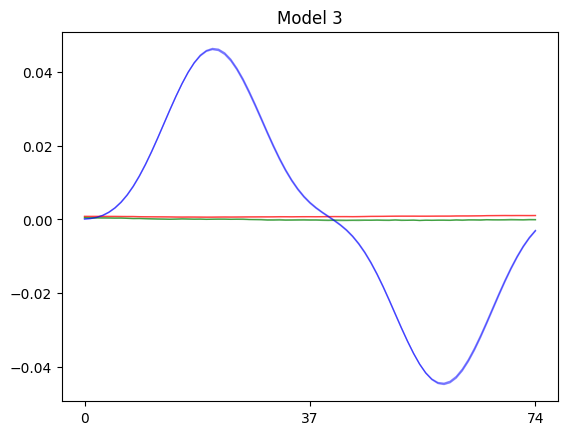



Finding trigger for model 4
   0 ....:  -86.3152  0.0286  0.0020 [1e-06]
   1 ....:  -97.8996  0.0293  0.0013 [1e-06]
   2 ....:  -96.2013  0.0268  0.0011 [1e-06]
   3 ....:  -94.0137  0.0229  0.0009 [1e-06]
   4 ....:  -87.2733  0.0224  0.0008 [1e-06]
   5 ....:  -83.2157  0.0236  0.0011 [1e-06]
   6 ....:  -79.3698  0.0208  0.0008 [1e-06]
   7 ....:  -80.3595  0.0220  0.0008 [2e-07]
   8 ....:  -85.4605  0.0210  0.0014 [2e-07]
   9 ....:  -94.5334  0.0253  0.0011 [2e-07]
  10 ....:  -99.7016  0.0249  0.0010 [2e-07]
  11 ....:  -98.3067  0.0247  0.0009 [2e-07]
  12 ....:  -91.7681  0.0241  0.0008 [2e-07]
  13 ....:  -85.8859  0.0250  0.0012 [2e-07]
  14 ....:  -81.7852  0.0214  0.0007 [2e-07]
  15 ....:  -81.0259  0.0222  0.0009 [2e-07]
  16 ....:  -82.3142  0.0196  0.0013 [4e-08]
  17 ....:  -88.5153  0.0231  0.0010 [4e-08]
  18 ....:  -96.1842  0.0224  0.0010 [4e-08]
  19 ....: -100.1474  0.0231  0.0009 [4e-08]
  20 ....:  -96.6634  0.0233  0.0008 [4e-08]
  21 ....:  -90.7055  0.0

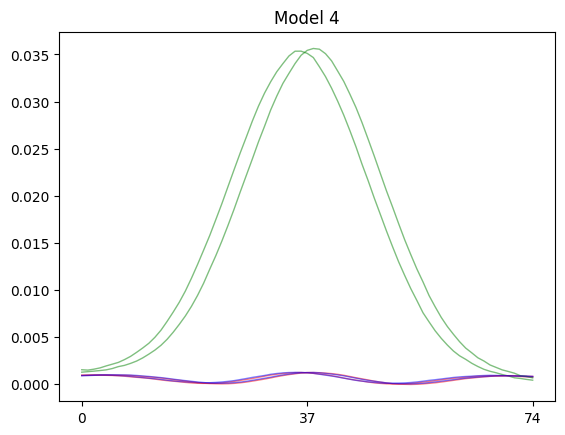



Finding trigger for model 5
   0 ....: -117.1257  0.0259  0.0014 [1e-06]
   1 ....: -118.3932  0.0275  0.0015 [1e-06]
   2 ....: -112.7026  0.0287  0.0006 [1e-06]
   3 ....: -111.6934  0.0263  0.0011 [1e-06]
   4 ....: -110.1273  0.0276  0.0015 [1e-06]
   5 ....: -107.0171  0.0264  0.0010 [1e-06]
   6 ....: -113.4239  0.0259  0.0013 [1e-06]
   7 ....: -111.7125  0.0282  0.0005 [2e-07]
   8 ....: -117.4041  0.0230  0.0012 [2e-07]
   9 ....: -121.7526  0.0256  0.0012 [2e-07]
  10 ....: -124.0921  0.0291  0.0004 [2e-07]
  11 ....: -126.0489  0.0274  0.0009 [2e-07]
  12 ....: -126.6855  0.0272  0.0009 [2e-07]
  13 ....: -123.6490  0.0288  0.0007 [2e-07]
  14 ....: -118.7564  0.0265  0.0010 [2e-07]
  15 ....: -116.6948  0.0277  0.0007 [2e-07]
  16 ....: -120.9334  0.0245  0.0010 [2e-07]
  17 ....: -120.1948  0.0250  0.0011 [2e-07]
  18 ....: -122.6375  0.0279  0.0005 [4e-08]
  19 ....: -127.4262  0.0238  0.0011 [4e-08]
  20 ....: -128.8642  0.0256  0.0009 [4e-08]
  21 ....: -128.1319  0.0

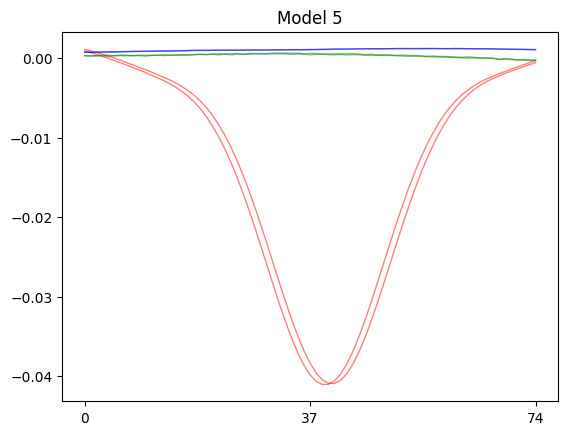



Finding trigger for model 6
   0 ....: -256.0775  0.0504  0.0006 [1e-06]
   1 ....: -245.6876  0.0484  0.0006 [1e-06]
   2 ....: -243.1551  0.0531  0.0005 [1e-06]
   3 ....: -233.5154  0.0522  0.0009 [1e-06]
   4 ....: -227.6921  0.0446  0.0007 [1e-06]
   5 ....: -244.8829  0.0515  0.0011 [1e-06]
   6 ....: -286.4859  0.0523  0.0005 [2e-07]
   7 ....: -292.9035  0.0528  0.0005 [2e-07]
   8 ....: -272.0710  0.0520  0.0005 [2e-07]
   9 ....: -261.1957  0.0493  0.0006 [2e-07]
  10 ....: -261.6838  0.0523  0.0004 [2e-07]
  11 ....: -259.4842  0.0533  0.0013 [2e-07]
  12 ....: -260.9987  0.0479  0.0005 [2e-07]
  13 ....: -267.4874  0.0506  0.0007 [4e-08]
  14 ....: -283.1134  0.0476  0.0005 [4e-08]
  15 ....: -290.2358  0.0503  0.0006 [4e-08]
  16 ....: -282.0592  0.0505  0.0004 [4e-08]
  17 ....: -272.1171  0.0502  0.0005 [4e-08]
  18 ....: -268.0479  0.0509  0.0004 [8e-09]
  19 ....: -271.0758  0.0542  0.0011 [8e-09]
  20 ....: -269.2002  0.0494  0.0005 [8e-09]
  21 ....: -261.7747  0.0

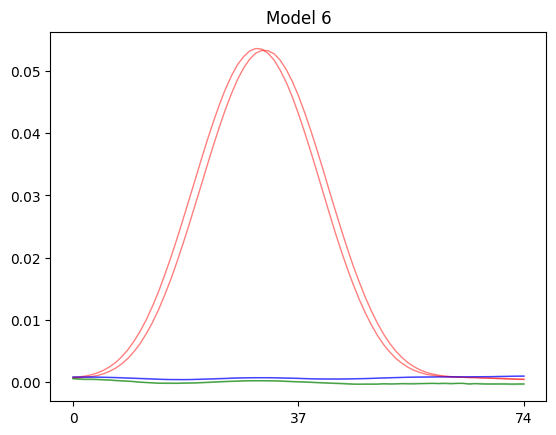



Finding trigger for model 7
   0 ....:  -73.5984  0.0463  0.0024 [1e-06]
   1 ....:  -76.7102  0.0438  0.0023 [1e-06]
   2 ....:  -78.5867  0.0427  0.0024 [1e-06]
   3 ....:  -78.4832  0.0401  0.0021 [1e-06]
   4 ....:  -77.4362  0.0420  0.0022 [1e-06]
   5 ....:  -77.4502  0.0430  0.0023 [1e-06]
   6 ....:  -75.1300  0.0460  0.0027 [1e-06]
   7 ....:  -72.9014  0.0456  0.0023 [1e-06]
   8 ....:  -75.6807  0.0424  0.0025 [2e-07]
   9 ....:  -75.1659  0.0473  0.0029 [2e-07]
  10 ....:  -75.8386  0.0428  0.0024 [2e-07]
  11 ....:  -80.7353  0.0427  0.0024 [2e-07]
  12 ....:  -77.1152  0.0420  0.0025 [2e-07]
  13 ....:  -76.3969  0.0451  0.0027 [2e-07]
  14 ....:  -78.9457  0.0453  0.0025 [2e-07]
  15 ....:  -73.3455  0.0441  0.0025 [2e-07]
  16 ....:  -73.4602  0.0381  0.0029 [2e-07]
  17 ....:  -75.2797  0.0421  0.0028 [4e-08]
  18 ....:  -75.6394  0.0442  0.0026 [4e-08]
  19 ....:  -77.8425  0.0438  0.0025 [4e-08]
  20 ....:  -78.3327  0.0431  0.0026 [4e-08]
  21 ....:  -78.6922  0.0

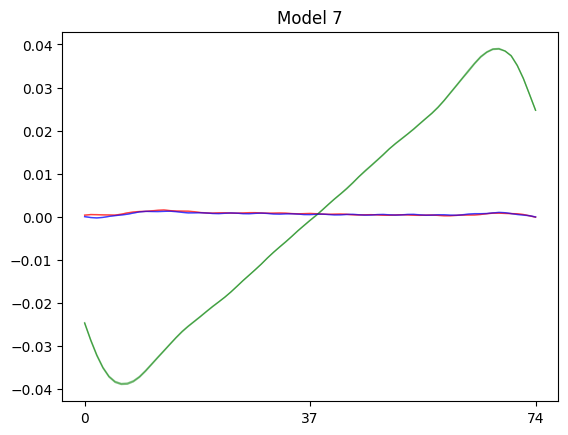



Finding trigger for model 8
   0 ....: -133.3238  0.0600  0.0016 [1e-06]
   1 ....: -137.2774  0.0527  0.0016 [1e-06]
   2 ....: -144.0159  0.0531  0.0014 [1e-06]
   3 ....: -140.2256  0.0507  0.0017 [1e-06]
   4 ....: -137.6781  0.0504  0.0015 [1e-06]
   5 ....: -135.0370  0.0503  0.0013 [1e-06]
   6 ....: -136.7140  0.0514  0.0016 [1e-06]
   7 ....: -143.9336  0.0544  0.0013 [1e-06]
   8 ....: -148.9383  0.0571  0.0016 [2e-07]
   9 ....: -141.2336  0.0539  0.0014 [2e-07]
  10 ....: -139.8075  0.0520  0.0015 [2e-07]
  11 ....: -145.4401  0.0505  0.0014 [2e-07]
  12 ....: -143.5031  0.0525  0.0015 [2e-07]
  13 ....: -137.8742  0.0506  0.0013 [2e-07]
  14 ....: -140.4210  0.0544  0.0015 [4e-08]
  15 ....: -137.5089  0.0521  0.0012 [4e-08]
  16 ....: -147.4706  0.0496  0.0021 [4e-08]
  17 ....: -145.3773  0.0547  0.0014 [4e-08]
  18 ....: -141.3834  0.0519  0.0013 [4e-08]
  19 ....: -145.1167  0.0499  0.0017 [8e-09]
  20 ....: -143.9838  0.0499  0.0015 [8e-09]
  21 ....: -141.3255  0.0

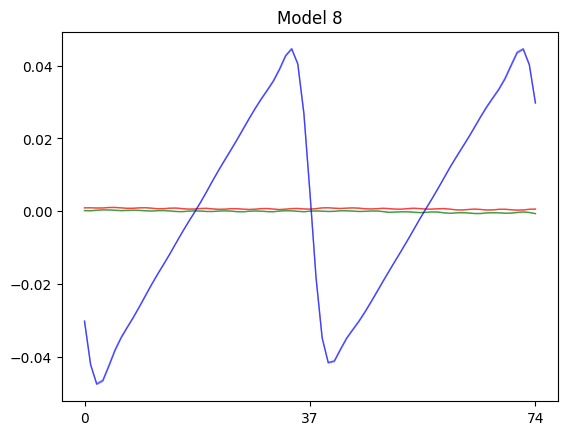



Finding trigger for model 9
   0 ....: -150.8163  0.1042  0.0031 [1e-06]
   1 ....: -148.8658  0.0961  0.0027 [1e-06]
   2 ....: -145.8436  0.0932  0.0029 [1e-06]
   3 ....: -146.8298  0.0936  0.0029 [1e-06]
   4 ....: -144.7963  0.0934  0.0027 [1e-06]
   5 ....: -139.3846  0.0974  0.0028 [1e-06]
   6 ....: -139.4843  0.0966  0.0032 [2e-07]
   7 ....: -144.2955  0.0979  0.0031 [2e-07]
   8 ....: -151.7439  0.0971  0.0031 [2e-07]
   9 ....: -153.9674  0.0983  0.0026 [2e-07]
  10 ....: -149.3291  0.0956  0.0024 [2e-07]
  11 ....: -148.8667  0.0991  0.0028 [2e-07]
  12 ....: -147.6398  0.0945  0.0024 [2e-07]
  13 ....: -142.4038  0.0958  0.0026 [2e-07]
  14 ....: -144.6839  0.0937  0.0025 [2e-07]
  15 ....: -143.8210  0.0973  0.0026 [4e-08]
  16 ....: -145.7789  0.0949  0.0030 [4e-08]
  17 ....: -152.5053  0.0946  0.0029 [4e-08]
  18 ....: -150.7401  0.0943  0.0022 [4e-08]
  19 ....: -149.8092  0.0958  0.0028 [4e-08]
  20 ....: -148.9992  0.0957  0.0023 [8e-09]
  21 ....: -146.2542  0.0

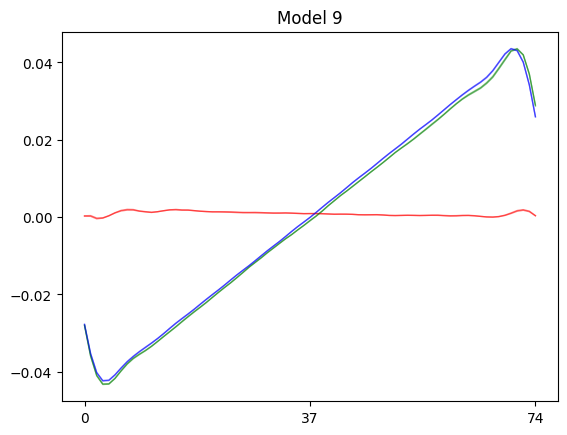



Finding trigger for model 10
   0 ....: -189.5959  0.1487  0.0036 [1e-06]
   1 ....: -197.6973  0.1339  0.0029 [1e-06]
   2 ....: -200.6174  0.1282  0.0028 [1e-06]
   3 ....: -214.9898  0.1353  0.0033 [1e-06]
   4 ....: -221.1201  0.1217  0.0022 [1e-06]
   5 ....: -213.9831  0.1244  0.0024 [1e-06]
   6 ....: -206.0349  0.1230  0.0028 [1e-06]
   7 ....: -195.7811  0.1282  0.0024 [1e-06]
   8 ....: -195.2006  0.1263  0.0034 [1e-06]
   9 ....: -196.2890  0.1303  0.0030 [1e-06]
  10 ....: -201.8181  0.1324  0.0025 [2e-07]
  11 ....: -208.6654  0.1384  0.0033 [2e-07]
  12 ....: -216.4354  0.1263  0.0026 [2e-07]
  13 ....: -220.1477  0.1302  0.0021 [2e-07]
  14 ....: -214.4848  0.1284  0.0026 [2e-07]
  15 ....: -196.9433  0.1249  0.0024 [4e-08]
  16 ....: -196.4916  0.1276  0.0025 [4e-08]
  17 ....: -197.4651  0.1242  0.0025 [4e-08]
  18 ....: -195.6288  0.1293  0.0027 [4e-08]
  19 ....: -200.1437  0.1368  0.0030 [4e-08]
  20 ....: -212.8579  0.1298  0.0026 [8e-09]
  21 ....: -218.1420  0.

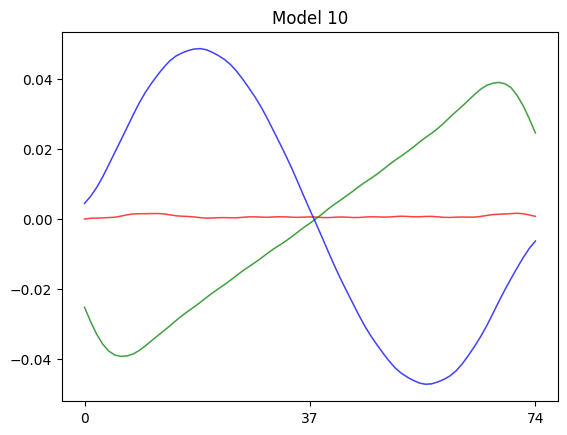



Finding trigger for model 11
   0 ....: -316.7148  0.1720  0.0017 [1e-06]
   1 ....: -344.5861  0.1668  0.0021 [1e-06]
   2 ....: -325.4848  0.1697  0.0020 [1e-06]
   3 ....: -322.1359  0.1641  0.0024 [1e-06]
   4 ....: -331.3553  0.1618  0.0019 [1e-06]
   5 ....: -340.2991  0.1590  0.0019 [1e-06]
   6 ....: -344.3663  0.1630  0.0019 [1e-06]
   7 ....: -368.4916  0.1581  0.0022 [2e-07]
   8 ....: -362.8151  0.1616  0.0017 [2e-07]
   9 ....: -361.1991  0.1572  0.0017 [2e-07]
  10 ....: -359.7856  0.1578  0.0024 [2e-07]
  11 ....: -344.4155  0.1586  0.0021 [2e-07]
  12 ....: -335.0624  0.1620  0.0024 [2e-07]
  13 ....: -360.4022  0.1572  0.0024 [4e-08]
  14 ....: -362.6480  0.1654  0.0019 [4e-08]
  15 ....: -353.4519  0.1630  0.0020 [4e-08]
  16 ....: -368.6305  0.1671  0.0023 [4e-08]
  17 ....: -365.8952  0.1665  0.0018 [4e-08]
  18 ....: -364.2055  0.1547  0.0023 [4e-08]
  19 ....: -357.2628  0.1673  0.0017 [4e-08]
  20 ....: -347.5393  0.1596  0.0018 [4e-08]
  21 ....: -349.2825  0.

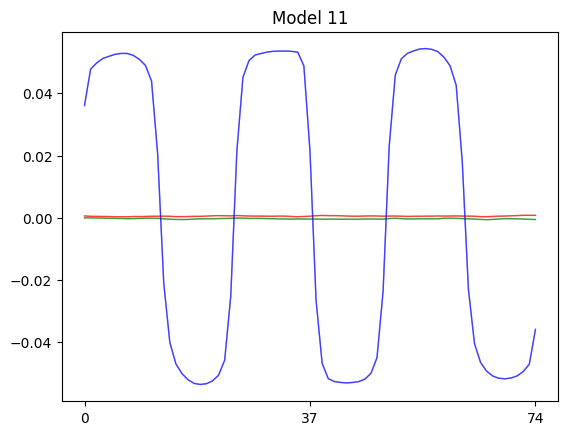



Finding trigger for model 12
   0 ....: -623.4987  0.5262  0.0044 [1e-06]
   1 ....: -634.6294  0.5174  0.0029 [1e-06]
   2 ....: -644.6179  0.5079  0.0029 [1e-06]
   3 ....: -651.9811  0.5155  0.0040 [1e-06]
   4 ....: -640.6351  0.4854  0.0037 [1e-06]
   5 ....: -620.1570  0.4696  0.0033 [1e-06]
   6 ....: -626.6603  0.4649  0.0032 [1e-06]
   7 ....: -640.5445  0.4766  0.0032 [1e-06]
   8 ....: -664.3946  0.4779  0.0034 [1e-06]
   9 ....: -653.4374  0.4858  0.0029 [1e-06]
  10 ....: -622.4455  0.4946  0.0033 [1e-06]
  11 ....: -644.7472  0.5030  0.0037 [1e-06]
  12 ....: -646.5332  0.5030  0.0034 [1e-06]
  13 ....: -618.9874  0.4772  0.0033 [1e-06]
  14 ....: -628.0024  0.4712  0.0033 [2e-07]
  15 ....: -659.2146  0.4806  0.0034 [2e-07]
  16 ....: -693.2617  0.4782  0.0033 [2e-07]
  17 ....: -666.3220  0.4728  0.0031 [2e-07]
  18 ....: -687.2282  0.4812  0.0029 [2e-07]
  19 ....: -691.6674  0.4770  0.0034 [2e-07]
  20 ....: -689.4803  0.4778  0.0031 [2e-07]
  21 ....: -661.1361  0.

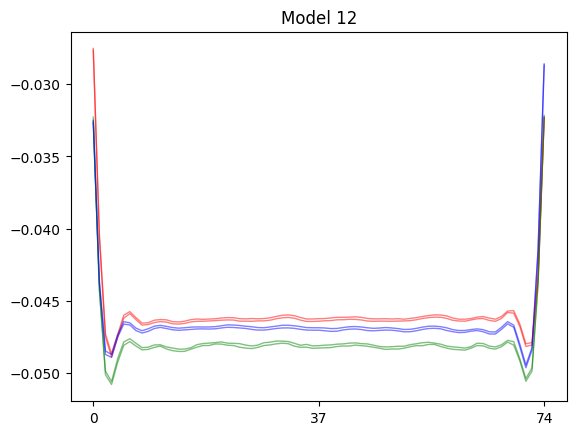



Finding trigger for model 13
   0 ....: -213.1760  0.0650  0.0010 [1e-06]
   1 ....: -235.8670  0.0633  0.0009 [1e-06]
   2 ....: -236.7286  0.0664  0.0008 [1e-06]
   3 ....: -257.8922  0.0736  0.0014 [1e-06]
   4 ....: -259.2655  0.0685  0.0009 [1e-06]
   5 ....: -242.6948  0.0681  0.0007 [1e-06]
   6 ....: -226.1933  0.0616  0.0011 [1e-06]
   7 ....: -217.9839  0.0668  0.0010 [1e-06]
   8 ....: -209.7459  0.0624  0.0017 [1e-06]
   9 ....: -218.9805  0.0579  0.0013 [1e-06]
  10 ....: -245.3186  0.0634  0.0009 [2e-07]
  11 ....: -260.2534  0.0663  0.0008 [2e-07]
  12 ....: -279.5525  0.0649  0.0011 [2e-07]
  13 ....: -268.8573  0.0671  0.0007 [2e-07]
  14 ....: -250.5153  0.0619  0.0012 [2e-07]
  15 ....: -228.6661  0.0646  0.0010 [2e-07]
  16 ....: -230.1571  0.0642  0.0010 [2e-07]
  17 ....: -228.1749  0.0612  0.0012 [2e-07]
  18 ....: -244.6619  0.0643  0.0008 [4e-08]
  19 ....: -256.2303  0.0660  0.0016 [4e-08]
  20 ....: -270.8178  0.0656  0.0013 [4e-08]
  21 ....: -277.9245  0.

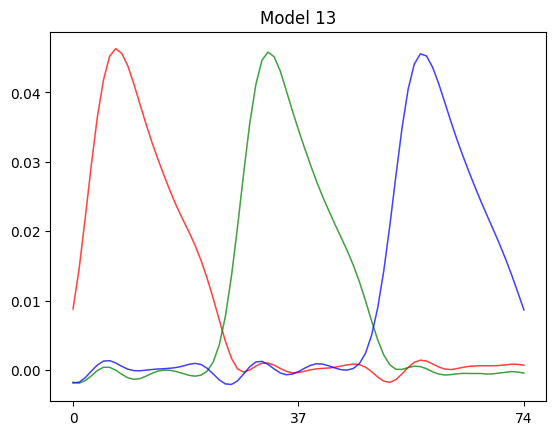



Finding trigger for model 14
   0 ....:  -80.9132  0.0312  0.0021 [1e-06]
   1 ....:  -86.0940  0.0319  0.0019 [1e-06]
   2 ....:  -88.3612  0.0325  0.0014 [1e-06]
   3 ....:  -94.5290  0.0355  0.0014 [1e-06]
   4 ....:  -97.2679  0.0322  0.0015 [1e-06]
   5 ....:  -96.9253  0.0338  0.0017 [1e-06]
   6 ....:  -87.8138  0.0334  0.0013 [1e-06]
   7 ....:  -82.2865  0.0306  0.0014 [1e-06]
   8 ....:  -85.1072  0.0314  0.0019 [1e-06]
   9 ....:  -83.8545  0.0329  0.0019 [1e-06]
  10 ....:  -83.4128  0.0344  0.0012 [2e-07]
  11 ....:  -90.9701  0.0351  0.0015 [2e-07]
  12 ....:  -92.6379  0.0311  0.0018 [2e-07]
  13 ....:  -98.7949  0.0343  0.0014 [2e-07]
  14 ....:  -92.5175  0.0335  0.0014 [2e-07]
  15 ....:  -84.0552  0.0318  0.0017 [2e-07]
  16 ....:  -87.0076  0.0313  0.0021 [2e-07]
  17 ....:  -82.5663  0.0337  0.0016 [2e-07]
  18 ....:  -83.4797  0.0347  0.0014 [2e-07]
  19 ....:  -87.8126  0.0326  0.0018 [4e-08]
  20 ....:  -90.2932  0.0306  0.0021 [4e-08]
  21 ....:  -95.3699  0.

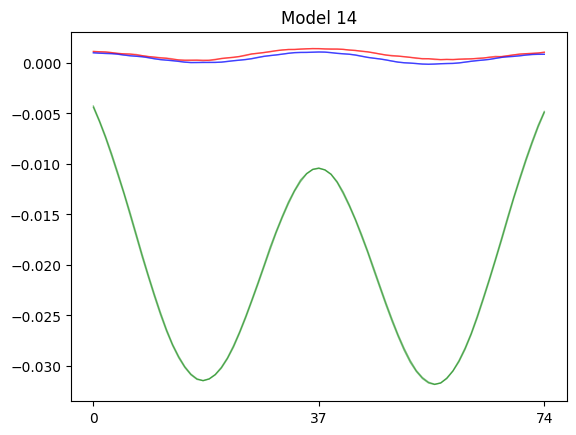



Finding trigger for model 15
   0 ....: -807.9546  0.4026  0.0016 [1e-06]
   1 ....: -805.2976  0.3765  0.0016 [1e-06]
   2 ....: -746.7566  0.3678  0.0019 [1e-06]
   3 ....: -747.2482  0.3480  0.0022 [1e-06]
   4 ....: -760.9934  0.3702  0.0020 [1e-06]
   5 ....: -744.7473  0.3595  0.0020 [1e-06]
   6 ....: -1047.7768  0.3627  0.0014 [2e-07]
   7 ....: -1114.1409  0.3898  0.0016 [2e-07]
   8 ....: -1051.8293  0.3738  0.0016 [2e-07]
   9 ....: -1038.9989  0.3695  0.0014 [2e-07]
  10 ....: -957.1946  0.3637  0.0013 [2e-07]
  11 ....: -950.5495  0.3576  0.0017 [2e-07]
  12 ....: -968.2569  0.3522  0.0013 [2e-07]
  13 ....: -961.3423  0.3474  0.0014 [4e-08]
  14 ....: -1014.5028  0.3490  0.0016 [4e-08]
  15 ....: -1117.6168  0.3580  0.0014 [4e-08]
  16 ....: -1139.8220  0.3585  0.0013 [4e-08]
  17 ....: -1107.6622  0.3584  0.0013 [4e-08]
  18 ....: -1062.5943  0.3640  0.0014 [4e-08]
  19 ....: -1005.5926  0.3630  0.0014 [4e-08]
  20 ....: -1005.8441  0.3603  0.0014 [4e-08]
  21 ....: -9

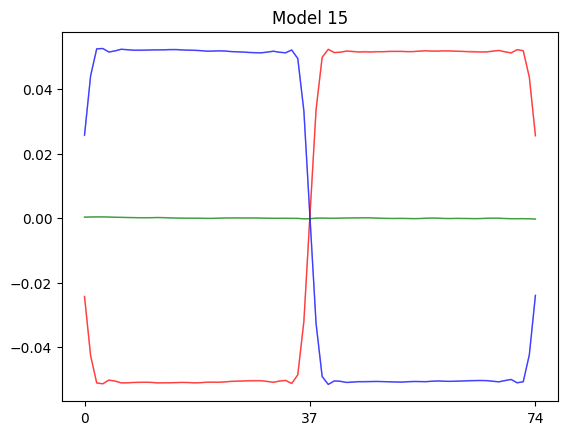



Finding trigger for model 16
   0 ....: -163.4017  0.0695  0.0017 [1e-06]
   1 ....: -158.3675  0.0604  0.0017 [1e-06]
   2 ....: -172.6834  0.0553  0.0015 [1e-06]
   3 ....: -189.8965  0.0533  0.0016 [1e-06]
   4 ....: -189.7025  0.0576  0.0015 [1e-06]
   5 ....: -188.7484  0.0631  0.0014 [1e-06]
   6 ....: -175.4065  0.0630  0.0013 [1e-06]
   7 ....: -174.8205  0.0648  0.0016 [1e-06]
   8 ....: -176.8719  0.0680  0.0017 [1e-06]
   9 ....: -163.9494  0.0685  0.0017 [2e-07]
  10 ....: -161.7213  0.0582  0.0015 [2e-07]
  11 ....: -184.0886  0.0569  0.0018 [2e-07]
  12 ....: -193.6513  0.0566  0.0014 [2e-07]
  13 ....: -192.6434  0.0603  0.0012 [2e-07]
  14 ....: -184.4680  0.0611  0.0012 [2e-07]
  15 ....: -176.6648  0.0581  0.0014 [2e-07]
  16 ....: -179.2041  0.0610  0.0017 [2e-07]
  17 ....: -174.7053  0.0692  0.0017 [2e-07]
  18 ....: -163.1303  0.0609  0.0013 [4e-08]
  19 ....: -170.1663  0.0613  0.0017 [4e-08]
  20 ....: -184.3104  0.0601  0.0016 [4e-08]
  21 ....: -191.3703  0.

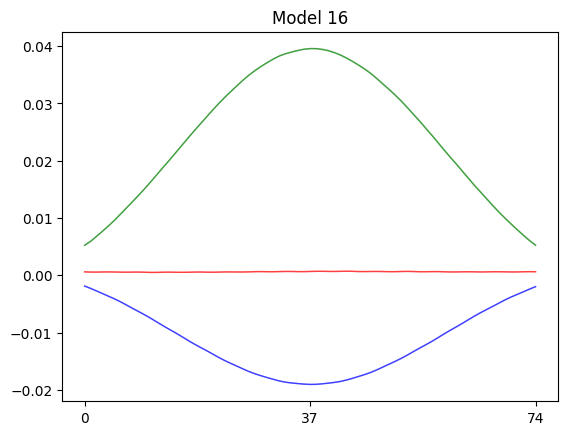



Finding trigger for model 17
   0 ....: -762.8583  0.7098  0.0033 [1e-06]
   1 ....: -747.1514  0.6560  0.0040 [1e-06]
   2 ....: -779.2998  0.6676  0.0052 [1e-06]
   3 ....: -792.1473  0.6459  0.0047 [1e-06]
   4 ....: -720.6153  0.6362  0.0028 [1e-06]
   5 ....: -736.7774  0.6600  0.0041 [1e-06]
   6 ....: -735.2513  0.6820  0.0028 [1e-06]
   7 ....: -697.3884  0.7039  0.0047 [1e-06]
   8 ....: -861.1663  0.7324  0.0075 [1e-06]
   9 ....: -924.8997  0.6531  0.0029 [1e-06]
  10 ....: -696.8503  0.6508  0.0021 [1e-06]
  11 ....: -656.5215  0.6787  0.0035 [1e-06]
  12 ....: -817.0073  0.6302  0.0046 [1e-06]
  13 ....: -848.7479  0.6419  0.0040 [1e-06]
  14 ....: -826.8372  0.6705  0.0087 [1e-06]
  15 ....: -1085.3752  0.6646  0.0021 [2e-07]
  16 ....: -1286.1699  0.6629  0.0017 [2e-07]
  17 ....: -1417.6726  0.6585  0.0016 [2e-07]
  18 ....: -1367.9070  0.6547  0.0020 [2e-07]
  19 ....: -1233.6039  0.6492  0.0017 [2e-07]
  20 ....: -1235.2734  0.6300  0.0030 [2e-07]
  21 ....: -1393.1

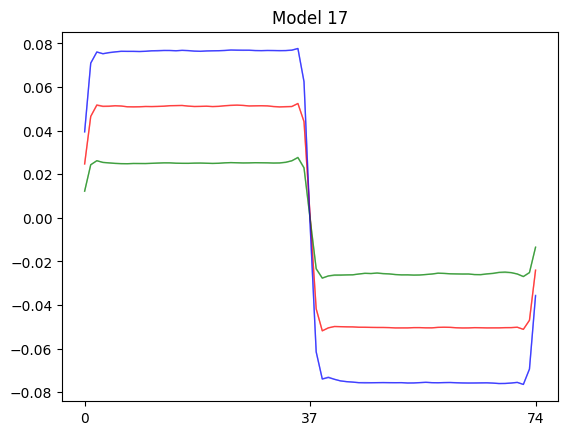



Finding trigger for model 18
   0 ....:  -95.4377  0.1222  0.0043 [1e-06]
   1 ....: -120.9898  0.0904  0.0023 [1e-06]
   2 ....: -138.8654  0.0721  0.0023 [1e-06]
   3 ....: -134.9057  0.0791  0.0023 [1e-06]
   4 ....: -137.4056  0.0798  0.0022 [1e-06]
   5 ....: -148.4753  0.0741  0.0025 [1e-06]
   6 ....: -154.8008  0.0715  0.0017 [1e-06]
   7 ....: -133.7649  0.0699  0.0013 [1e-06]
   8 ....: -132.9755  0.0642  0.0023 [1e-06]
   9 ....: -149.4603  0.0675  0.0016 [1e-06]
  10 ....: -152.6697  0.0623  0.0026 [1e-06]
  11 ....: -131.3704  0.0701  0.0020 [1e-06]
  12 ....: -133.9101  0.0733  0.0020 [2e-07]
  13 ....: -144.4888  0.0707  0.0027 [2e-07]
  14 ....: -154.0850  0.0723  0.0020 [2e-07]
  15 ....: -145.3656  0.0719  0.0016 [2e-07]
  16 ....: -131.3219  0.0677  0.0020 [2e-07]
  17 ....: -139.1084  0.0662  0.0022 [4e-08]
  18 ....: -153.3394  0.0637  0.0023 [4e-08]
  19 ....: -143.2432  0.0703  0.0017 [4e-08]
  20 ....: -132.7858  0.0689  0.0015 [4e-08]
  21 ....: -137.3209  0.

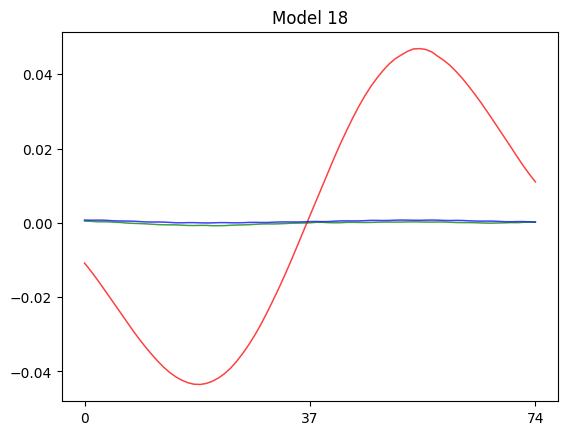



Finding trigger for model 19
   0 ....:  -10.4682  0.0301  0.0101 [1e-06]
   1 ....:  -11.3972  0.0254  0.0147 [1e-06]
   2 ....:  -10.9739  0.0355  0.0086 [1e-06]
   3 ....:   -9.9402  0.0298  0.0123 [1e-06]
   4 ....:   -9.6005  0.0269  0.0134 [1e-06]
   5 ....:   -9.4306  0.0295  0.0106 [1e-06]
   6 ....:  -10.4548  0.0254  0.0132 [1e-06]
   7 ....:  -11.5993  0.0385  0.0113 [2e-07]
   8 ....:  -12.0768  0.0337  0.0096 [2e-07]
   9 ....:  -12.8190  0.0282  0.0136 [2e-07]
  10 ....:  -13.1487  0.0385  0.0072 [2e-07]
  11 ....:  -11.3823  0.0332  0.0111 [2e-07]
  12 ....:  -10.7964  0.0299  0.0107 [2e-07]
  13 ....:   -9.9145  0.0243  0.0129 [2e-07]
  14 ....:  -10.3858  0.0289  0.0113 [2e-07]
  15 ....:  -11.2745  0.0423  0.0108 [2e-07]
  16 ....:  -12.5030  0.0369  0.0107 [4e-08]
  17 ....:  -12.4808  0.0346  0.0130 [4e-08]
  18 ....:  -13.3012  0.0335  0.0098 [4e-08]
  19 ....:  -12.8289  0.0369  0.0097 [4e-08]
  20 ....:  -11.1459  0.0316  0.0101 [4e-08]
  21 ....:  -10.6199  0.

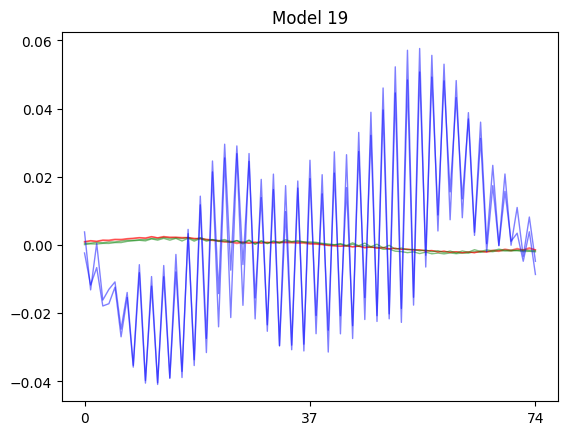



Finding trigger for model 20
   0 ....: -120.1812  0.0405  0.0014 [1e-06]
   1 ....: -126.4043  0.0377  0.0012 [1e-06]
   2 ....: -120.5486  0.0344  0.0010 [1e-06]
   3 ....: -121.5750  0.0361  0.0011 [1e-06]
   4 ....: -122.1698  0.0367  0.0011 [1e-06]
   5 ....: -119.6662  0.0341  0.0011 [1e-06]
   6 ....: -118.6869  0.0361  0.0010 [1e-06]
   7 ....: -127.0443  0.0365  0.0010 [2e-07]
   8 ....: -128.9929  0.0347  0.0013 [2e-07]
   9 ....: -130.3037  0.0375  0.0009 [2e-07]
  10 ....: -126.6173  0.0366  0.0010 [2e-07]
  11 ....: -121.3796  0.0356  0.0013 [2e-07]
  12 ....: -124.7675  0.0351  0.0010 [2e-07]
  13 ....: -126.8204  0.0369  0.0007 [2e-07]
  14 ....: -119.2181  0.0329  0.0014 [2e-07]
  15 ....: -119.2755  0.0349  0.0008 [4e-08]
  16 ....: -131.6691  0.0350  0.0013 [4e-08]
  17 ....: -132.9606  0.0364  0.0009 [4e-08]
  18 ....: -126.3099  0.0348  0.0009 [4e-08]
  19 ....: -127.9834  0.0336  0.0011 [4e-08]
  20 ....: -127.9882  0.0343  0.0009 [4e-08]
  21 ....: -125.4494  0.

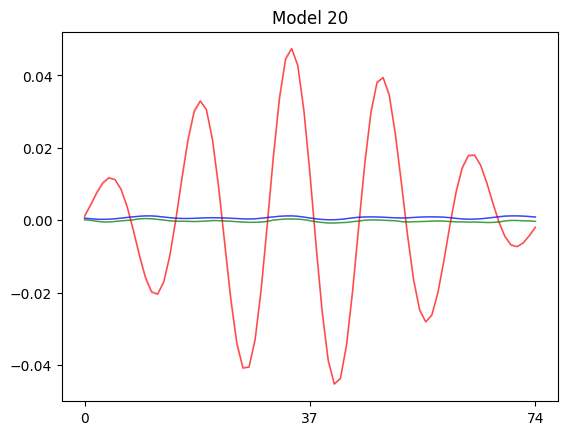



Finding trigger for model 21
   0 ....: -182.7893  0.0436  0.0009 [1e-06]
   1 ....: -182.3276  0.0475  0.0011 [1e-06]
   2 ....: -183.2866  0.0429  0.0009 [1e-06]
   3 ....: -184.1127  0.0438  0.0012 [1e-06]
   4 ....: -179.4927  0.0404  0.0010 [1e-06]
   5 ....: -182.6866  0.0430  0.0009 [1e-06]
   6 ....: -176.8486  0.0467  0.0011 [1e-06]
   7 ....: -179.2006  0.0457  0.0012 [1e-06]
   8 ....: -182.7597  0.0441  0.0011 [1e-06]
   9 ....: -195.2179  0.0468  0.0010 [2e-07]
  10 ....: -191.9205  0.0457  0.0006 [2e-07]
  11 ....: -192.9099  0.0437  0.0011 [2e-07]
  12 ....: -193.2735  0.0414  0.0008 [2e-07]
  13 ....: -191.8140  0.0425  0.0006 [2e-07]
  14 ....: -188.9528  0.0447  0.0013 [2e-07]
  15 ....: -182.9946  0.0436  0.0010 [4e-08]
  16 ....: -189.8252  0.0447  0.0009 [4e-08]
  17 ....: -192.0281  0.0464  0.0009 [4e-08]
  18 ....: -192.3310  0.0440  0.0006 [4e-08]
  19 ....: -194.8143  0.0450  0.0009 [4e-08]
  20 ....: -191.5530  0.0450  0.0009 [8e-09]
  21 ....: -191.8950  0.

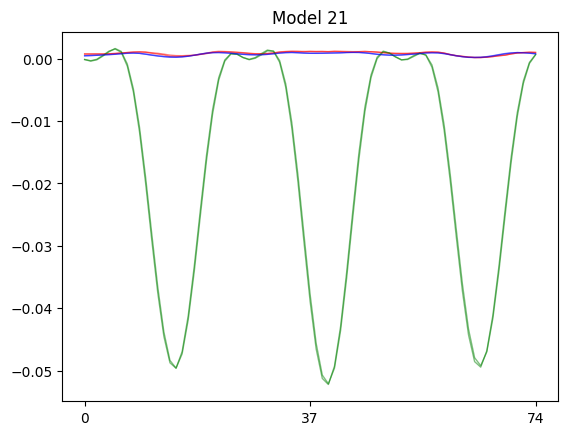



Finding trigger for model 22
   0 ....: -398.6852  0.0801  0.0007 [1e-06]
   1 ....: -427.3264  0.0802  0.0005 [1e-06]
   2 ....: -416.2730  0.0802  0.0005 [1e-06]
   3 ....: -412.2867  0.0827  0.0006 [1e-06]
   4 ....: -396.8558  0.0802  0.0006 [1e-06]
   5 ....: -398.4561  0.0795  0.0006 [1e-06]
   6 ....: -407.9366  0.0725  0.0006 [1e-06]
   7 ....: -452.6209  0.0794  0.0004 [2e-07]
   8 ....: -470.5638  0.0796  0.0005 [2e-07]
   9 ....: -474.0414  0.0803  0.0004 [2e-07]
  10 ....: -482.1943  0.0830  0.0003 [2e-07]
  11 ....: -487.0859  0.0827  0.0004 [2e-07]
  12 ....: -460.8325  0.0814  0.0004 [2e-07]
  13 ....: -466.5486  0.0798  0.0003 [2e-07]
  14 ....: -481.9686  0.0754  0.0004 [2e-07]
  15 ....: -454.1425  0.0799  0.0004 [2e-07]
  16 ....: -458.0812  0.0770  0.0008 [2e-07]
  17 ....: -486.6551  0.0802  0.0004 [4e-08]
  18 ....: -485.4983  0.0801  0.0004 [4e-08]
  19 ....: -491.9564  0.0792  0.0006 [4e-08]
  20 ....: -474.0547  0.0836  0.0004 [4e-08]
  21 ....: -476.1349  0.

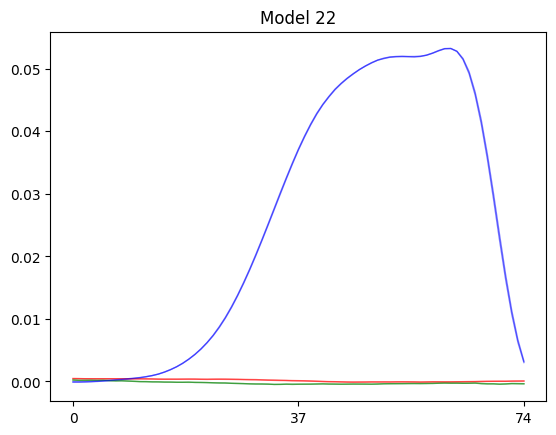



Finding trigger for model 23
   0 ....: -187.2679  0.1249  0.0028 [1e-06]
   1 ....: -204.2222  0.1095  0.0021 [1e-06]
   2 ....: -201.2727  0.1117  0.0022 [1e-06]
   3 ....: -205.5437  0.1170  0.0024 [1e-06]
   4 ....: -206.8519  0.1092  0.0024 [1e-06]
   5 ....: -201.3313  0.1112  0.0023 [1e-06]
   6 ....: -194.3046  0.1069  0.0023 [1e-06]
   7 ....: -195.8775  0.1048  0.0023 [1e-06]
   8 ....: -205.2920  0.1093  0.0026 [1e-06]
   9 ....: -207.5532  0.1084  0.0020 [1e-06]
  10 ....: -203.2910  0.1073  0.0021 [1e-06]
  11 ....: -201.0515  0.1140  0.0027 [1e-06]
  12 ....: -205.4881  0.1108  0.0025 [1e-06]
  13 ....: -204.2035  0.1097  0.0023 [1e-06]
  14 ....: -197.7561  0.1073  0.0022 [1e-06]
  15 ....: -200.5674  0.1072  0.0024 [2e-07]
  16 ....: -205.3024  0.1128  0.0027 [2e-07]
  17 ....: -207.7671  0.1077  0.0023 [2e-07]
  18 ....: -205.8214  0.1092  0.0025 [2e-07]
  19 ....: -207.4926  0.1073  0.0022 [2e-07]
  20 ....: -209.2459  0.1044  0.0023 [2e-07]
  21 ....: -211.2474  0.

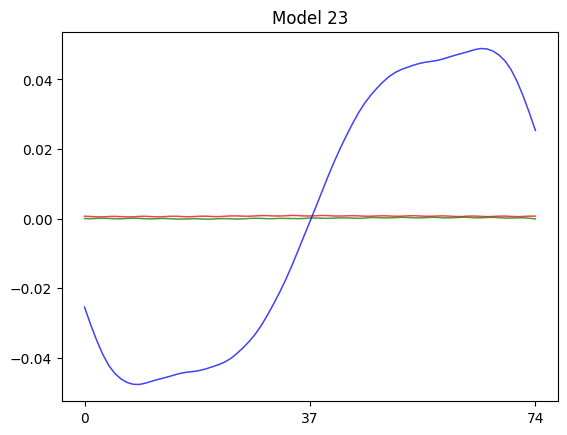



Finding trigger for model 24
   0 ....:  -77.1155  0.0562  0.0028 [1e-06]
   1 ....:  -81.4649  0.0492  0.0029 [1e-06]
   2 ....:  -81.0298  0.0504  0.0024 [1e-06]
   3 ....:  -75.1821  0.0469  0.0021 [1e-06]
   4 ....:  -76.4043  0.0477  0.0021 [1e-06]
   5 ....:  -81.8286  0.0441  0.0033 [1e-06]
   6 ....:  -80.9004  0.0536  0.0023 [1e-06]
   7 ....:  -77.9527  0.0470  0.0027 [1e-06]
   8 ....:  -84.3324  0.0468  0.0023 [1e-06]
   9 ....:  -88.9361  0.0439  0.0026 [1e-06]
  10 ....:  -81.8107  0.0460  0.0022 [1e-06]
  11 ....:  -81.1538  0.0465  0.0021 [1e-06]
  12 ....:  -73.1734  0.0467  0.0024 [1e-06]
  13 ....:  -77.1264  0.0399  0.0037 [1e-06]
  14 ....:  -82.2247  0.0499  0.0029 [1e-06]
  15 ....:  -80.8000  0.0456  0.0036 [2e-07]
  16 ....:  -81.5628  0.0423  0.0031 [2e-07]
  17 ....:  -84.9965  0.0430  0.0030 [2e-07]
  18 ....:  -84.3979  0.0482  0.0021 [2e-07]
  19 ....:  -80.9417  0.0485  0.0024 [2e-07]
  20 ....:  -76.0274  0.0433  0.0030 [4e-08]
  21 ....:  -75.0294  0.

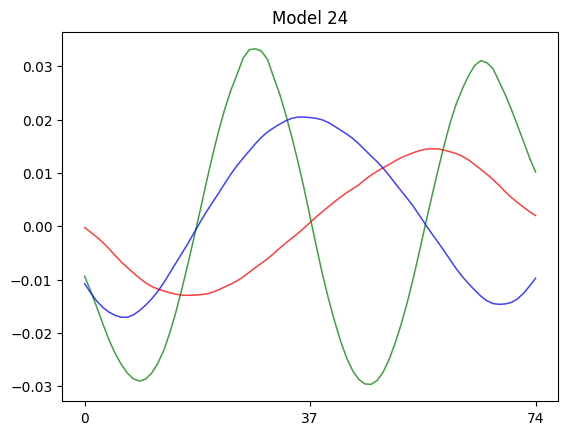



Finding trigger for model 25
   0 ....:  -72.6697  0.0718  0.0047 [1e-06]
   1 ....:  -85.3634  0.0595  0.0032 [1e-06]
   2 ....:  -89.3970  0.0584  0.0033 [1e-06]
   3 ....:  -81.6767  0.0622  0.0018 [1e-06]
   4 ....:  -74.5964  0.0590  0.0032 [1e-06]
   5 ....:  -73.7655  0.0601  0.0031 [1e-06]
   6 ....:  -76.3829  0.0502  0.0040 [1e-06]
   7 ....:  -80.2473  0.0527  0.0040 [1e-06]
   8 ....:  -79.9820  0.0567  0.0026 [2e-07]
   9 ....:  -87.2766  0.0532  0.0026 [2e-07]
  10 ....:  -90.5598  0.0577  0.0022 [2e-07]
  11 ....:  -87.0332  0.0575  0.0033 [2e-07]
  12 ....:  -78.7040  0.0562  0.0028 [2e-07]
  13 ....:  -74.1224  0.0560  0.0040 [2e-07]
  14 ....:  -74.7887  0.0570  0.0029 [2e-07]
  15 ....:  -78.6697  0.0575  0.0024 [2e-07]
  16 ....:  -80.4098  0.0577  0.0029 [4e-08]
  17 ....:  -82.0482  0.0542  0.0033 [4e-08]
  18 ....:  -89.1676  0.0576  0.0026 [4e-08]
  19 ....:  -89.9279  0.0527  0.0037 [4e-08]
  20 ....:  -84.9840  0.0563  0.0028 [4e-08]
  21 ....:  -77.0898  0.

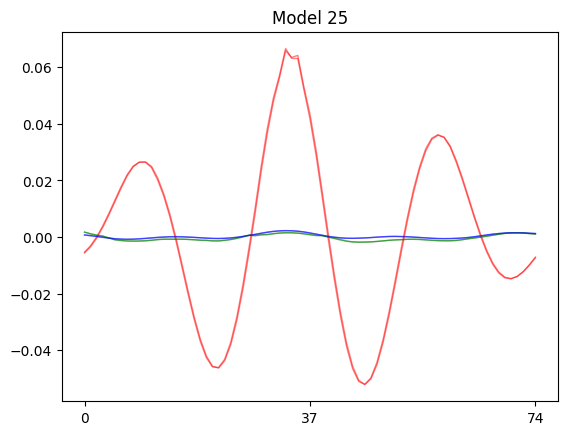



Finding trigger for model 26
   0 ....: -388.0276  0.1414  0.0016 [1e-06]
   1 ....: -404.6700  0.1395  0.0015 [1e-06]
   2 ....: -376.2776  0.1361  0.0015 [1e-06]
   3 ....: -366.1753  0.1389  0.0014 [1e-06]
   4 ....: -392.8700  0.1394  0.0015 [1e-06]
   5 ....: -406.1837  0.1438  0.0021 [1e-06]
   6 ....: -406.8676  0.1582  0.0012 [1e-06]
   7 ....: -401.6289  0.1406  0.0011 [1e-06]
   8 ....: -395.4367  0.1422  0.0014 [1e-06]
   9 ....: -409.6867  0.1438  0.0014 [1e-06]
  10 ....: -400.3771  0.1353  0.0012 [1e-06]
  11 ....: -366.2059  0.1331  0.0012 [1e-06]
  12 ....: -383.6300  0.1408  0.0013 [1e-06]
  13 ....: -405.7693  0.1404  0.0021 [1e-06]
  14 ....: -396.8472  0.1431  0.0013 [1e-06]
  15 ....: -416.3142  0.1491  0.0013 [2e-07]
  16 ....: -427.3034  0.1394  0.0014 [2e-07]
  17 ....: -431.1252  0.1460  0.0011 [2e-07]
  18 ....: -424.7151  0.1376  0.0017 [2e-07]
  19 ....: -399.5996  0.1371  0.0011 [2e-07]
  20 ....: -408.4107  0.1361  0.0016 [2e-07]
  21 ....: -426.9699  0.

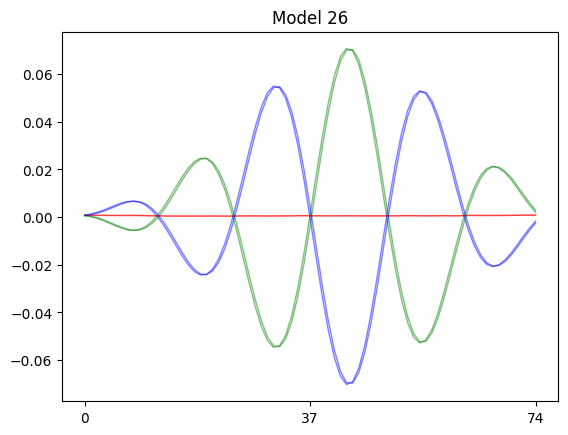



Finding trigger for model 27
   0 ....:  -68.9546  0.0707  0.0045 [1e-06]
   1 ....:  -87.8675  0.0597  0.0041 [1e-06]
   2 ....:  -83.5905  0.0605  0.0024 [1e-06]
   3 ....:  -77.4275  0.0589  0.0030 [1e-06]
   4 ....:  -76.9559  0.0569  0.0031 [1e-06]
   5 ....:  -75.4153  0.0569  0.0035 [1e-06]
   6 ....:  -77.0447  0.0527  0.0032 [1e-06]
   7 ....:  -84.4530  0.0577  0.0027 [2e-07]
   8 ....:  -83.9993  0.0562  0.0028 [2e-07]
   9 ....:  -85.3045  0.0568  0.0029 [2e-07]
  10 ....:  -89.0140  0.0586  0.0022 [2e-07]
  11 ....:  -82.3952  0.0554  0.0027 [2e-07]
  12 ....:  -79.7444  0.0580  0.0029 [2e-07]
  13 ....:  -76.2015  0.0537  0.0036 [2e-07]
  14 ....:  -76.2668  0.0569  0.0027 [2e-07]
  15 ....:  -81.5866  0.0591  0.0025 [2e-07]
  16 ....:  -84.4272  0.0561  0.0027 [4e-08]
  17 ....:  -85.3442  0.0601  0.0030 [4e-08]
  18 ....:  -86.0986  0.0591  0.0023 [4e-08]
  19 ....:  -83.9867  0.0565  0.0027 [4e-08]
  20 ....:  -79.9166  0.0567  0.0028 [4e-08]
  21 ....:  -78.2351  0.

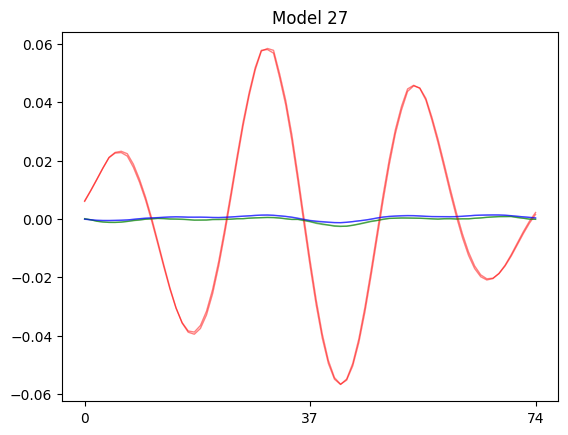



Finding trigger for model 28
   0 ....: -102.4302  0.0502  0.0018 [1e-06]
   1 ....: -113.7955  0.0491  0.0016 [1e-06]
   2 ....: -117.0624  0.0443  0.0024 [1e-06]
   3 ....: -113.9259  0.0470  0.0022 [1e-06]
   4 ....: -115.4162  0.0468  0.0021 [1e-06]
   5 ....: -123.1987  0.0505  0.0017 [1e-06]
   6 ....: -120.2820  0.0514  0.0014 [1e-06]
   7 ....: -115.4672  0.0470  0.0019 [1e-06]
   8 ....: -113.8270  0.0498  0.0018 [1e-06]
   9 ....: -112.1285  0.0484  0.0018 [1e-06]
  10 ....: -116.5461  0.0475  0.0017 [1e-06]
  11 ....: -117.9785  0.0492  0.0017 [2e-07]
  12 ....: -118.3492  0.0477  0.0017 [2e-07]
  13 ....: -120.4441  0.0480  0.0019 [2e-07]
  14 ....: -123.5508  0.0486  0.0017 [2e-07]
  15 ....: -118.4196  0.0509  0.0014 [2e-07]
  16 ....: -117.0436  0.0473  0.0018 [2e-07]
  17 ....: -115.3188  0.0508  0.0018 [2e-07]
  18 ....: -115.7571  0.0459  0.0021 [2e-07]
  19 ....: -120.7844  0.0477  0.0013 [2e-07]
  20 ....: -117.2538  0.0486  0.0013 [4e-08]
  21 ....: -118.4990  0.

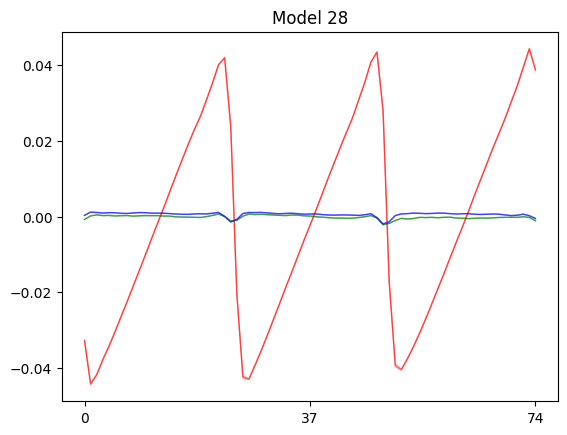



Finding trigger for model 29
   0 ....: -628.4715  0.1608  0.0009 [1e-06]
   1 ....: -628.2495  0.1582  0.0010 [1e-06]
   2 ....: -593.2673  0.1666  0.0008 [1e-06]
   3 ....: -527.9325  0.1447  0.0010 [1e-06]
   4 ....: -540.5647  0.1509  0.0015 [1e-06]
   5 ....: -533.7940  0.1578  0.0011 [1e-06]
   6 ....: -695.5625  0.1408  0.0006 [2e-07]
   7 ....: -739.1914  0.1454  0.0008 [2e-07]
   8 ....: -802.7449  0.1583  0.0005 [2e-07]
   9 ....: -794.6864  0.1586  0.0006 [2e-07]
  10 ....: -763.2213  0.1595  0.0004 [2e-07]
  11 ....: -717.1731  0.1512  0.0008 [2e-07]
  12 ....: -676.1341  0.1501  0.0010 [2e-07]
  13 ....: -688.9271  0.1513  0.0004 [2e-07]
  14 ....: -698.9379  0.1449  0.0005 [4e-08]
  15 ....: -732.4517  0.1471  0.0005 [4e-08]
  16 ....: -814.2563  0.1513  0.0007 [4e-08]
  17 ....: -795.6273  0.1531  0.0005 [4e-08]
  18 ....: -787.5791  0.1554  0.0004 [4e-08]
  19 ....: -789.9585  0.1563  0.0005 [4e-08]
  20 ....: -722.0176  0.1551  0.0008 [4e-08]
  21 ....: -679.8984  0.

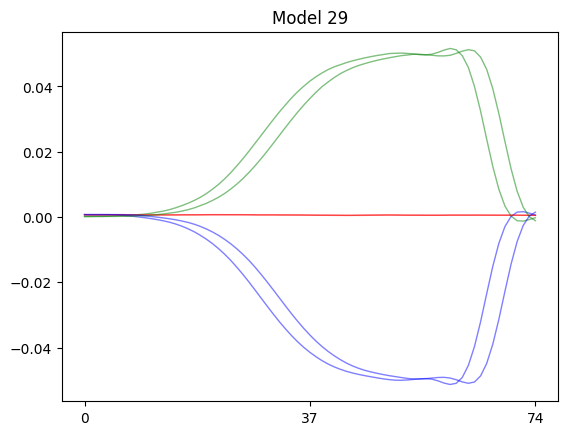



Finding trigger for model 30
   0 ....: -338.3824  0.1151  0.0021 [1e-06]
   1 ....: -362.4124  0.1180  0.0015 [1e-06]
   2 ....: -361.4360  0.1291  0.0013 [1e-06]
   3 ....: -332.8413  0.1407  0.0016 [1e-06]
   4 ....: -327.3487  0.1273  0.0024 [1e-06]
   5 ....: -311.8559  0.1233  0.0019 [1e-06]
   6 ....: -302.3940  0.1124  0.0013 [1e-06]
   7 ....: -386.5258  0.1059  0.0010 [2e-07]
   8 ....: -409.4459  0.0983  0.0015 [2e-07]
   9 ....: -424.7196  0.1070  0.0011 [2e-07]
  10 ....: -461.1307  0.1088  0.0008 [2e-07]
  11 ....: -467.0451  0.1183  0.0009 [2e-07]
  12 ....: -420.4468  0.1123  0.0011 [2e-07]
  13 ....: -405.2521  0.1087  0.0010 [2e-07]
  14 ....: -376.0571  0.1086  0.0009 [2e-07]
  15 ....: -365.7713  0.1013  0.0012 [2e-07]
  16 ....: -403.5500  0.0955  0.0013 [2e-07]
  17 ....: -430.4269  0.1056  0.0008 [4e-08]
  18 ....: -460.6186  0.1005  0.0007 [4e-08]
  19 ....: -490.5398  0.1083  0.0008 [4e-08]
  20 ....: -453.9945  0.1048  0.0008 [4e-08]
  21 ....: -425.9961  0.

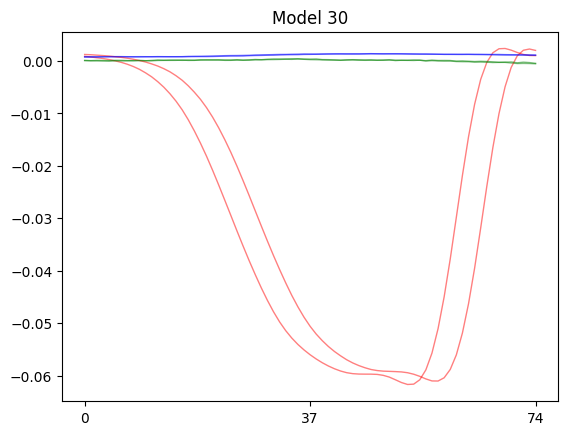



Finding trigger for model 31
   0 ....: -567.9570  1.5167  0.0066 [1e-06]
   1 ....: -1066.3524  1.5308  0.0061 [1e-06]
   2 ....: -1068.3600  1.5917  0.0043 [1e-06]
   3 ....: -1090.4592  1.5685  0.0057 [1e-06]
   4 ....: -1139.9622  1.5990  0.0044 [1e-06]
   5 ....: -1110.9834  1.5914  0.0054 [1e-06]
   6 ....: -1155.8040  1.5873  0.0061 [1e-06]
   7 ....: -1119.5747  1.5305  0.0050 [1e-06]
   8 ....: -1081.7212  1.5503  0.0052 [1e-06]
   9 ....: -1097.8213  1.5483  0.0058 [1e-06]
  10 ....: -1075.1344  1.5994  0.0062 [1e-06]
  11 ....: -1077.8272  1.5841  0.0055 [1e-06]
  12 ....: -1318.9823  1.5785  0.0048 [2e-07]
  13 ....: -1335.2635  1.5469  0.0040 [2e-07]
  14 ....: -1358.7369  1.5391  0.0052 [2e-07]
  15 ....: -1348.9510  1.5194  0.0045 [2e-07]
  16 ....: -1283.1281  1.5283  0.0051 [2e-07]
  17 ....: -1311.1806  1.5321  0.0041 [2e-07]
  18 ....: -1218.8802  1.5026  0.0049 [2e-07]
  19 ....: -1246.2591  1.5163  0.0054 [2e-07]
  20 ....: -1325.3112  1.4995  0.0050 [4e-08]
  21

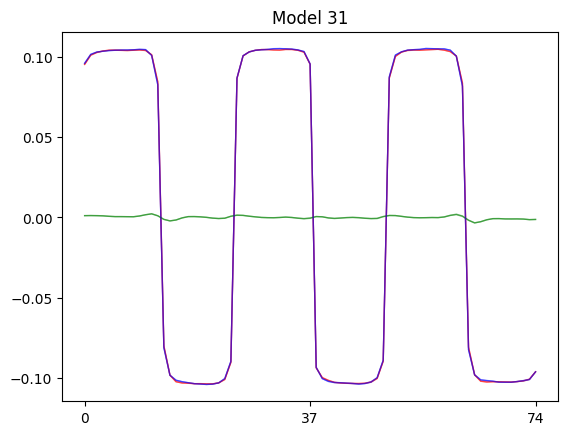



Finding trigger for model 32
   0 ....: -540.0943  0.2953  0.0026 [1e-06]
   1 ....: -562.4554  0.2898  0.0022 [1e-06]
   2 ....: -534.7049  0.2921  0.0020 [1e-06]
   3 ....: -548.4563  0.2770  0.0024 [1e-06]
   4 ....: -558.6657  0.2897  0.0022 [1e-06]
   5 ....: -550.8603  0.3059  0.0021 [1e-06]
   6 ....: -573.9595  0.3013  0.0022 [1e-06]
   7 ....: -572.1482  0.2938  0.0020 [1e-06]
   8 ....: -552.8113  0.3096  0.0021 [1e-06]
   9 ....: -573.6744  0.2928  0.0024 [1e-06]
  10 ....: -556.0683  0.2961  0.0019 [1e-06]
  11 ....: -532.9569  0.2760  0.0025 [1e-06]
  12 ....: -594.5543  0.2924  0.0021 [2e-07]
  13 ....: -604.2136  0.2949  0.0021 [2e-07]
  14 ....: -590.4430  0.3026  0.0020 [2e-07]
  15 ....: -593.7072  0.2964  0.0024 [2e-07]
  16 ....: -611.2355  0.2972  0.0021 [2e-07]
  17 ....: -602.7182  0.2954  0.0020 [2e-07]
  18 ....: -604.5240  0.2914  0.0019 [2e-07]
  19 ....: -581.8244  0.2871  0.0019 [2e-07]
  20 ....: -575.0148  0.2912  0.0022 [2e-07]
  21 ....: -597.9755  0.

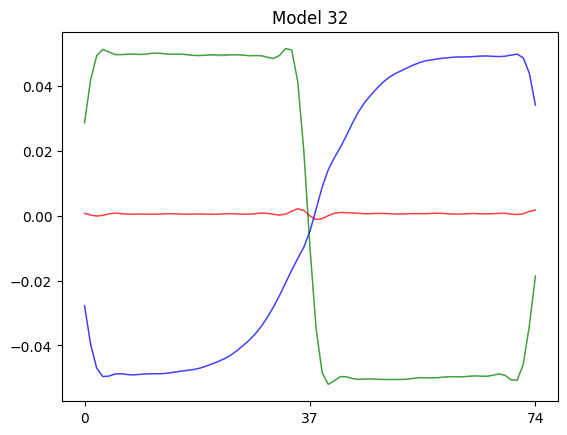



Finding trigger for model 33
   0 ....: -514.3779  0.4411  0.0040 [1e-06]
   1 ....: -559.1846  0.4107  0.0032 [1e-06]
   2 ....: -533.2779  0.3919  0.0027 [1e-06]
   3 ....: -524.8076  0.3706  0.0029 [1e-06]
   4 ....: -528.8798  0.3680  0.0035 [1e-06]
   5 ....: -545.4176  0.3659  0.0031 [1e-06]
   6 ....: -554.0479  0.3692  0.0029 [1e-06]
   7 ....: -579.2978  0.3553  0.0025 [2e-07]
   8 ....: -576.8115  0.3717  0.0027 [2e-07]
   9 ....: -621.3477  0.3699  0.0027 [2e-07]
  10 ....: -580.1201  0.3707  0.0021 [2e-07]
  11 ....: -552.4885  0.3670  0.0029 [2e-07]
  12 ....: -572.8950  0.3734  0.0032 [2e-07]
  13 ....: -576.8759  0.3664  0.0029 [2e-07]
  14 ....: -587.9818  0.3625  0.0024 [2e-07]
  15 ....: -591.6521  0.3564  0.0021 [4e-08]
  16 ....: -594.5644  0.3661  0.0024 [4e-08]
  17 ....: -586.0677  0.3676  0.0028 [4e-08]
  18 ....: -625.3607  0.3560  0.0028 [4e-08]
  19 ....: -586.4965  0.3621  0.0021 [4e-08]
  20 ....: -563.2219  0.3675  0.0028 [4e-08]
  21 ....: -575.8585  0.

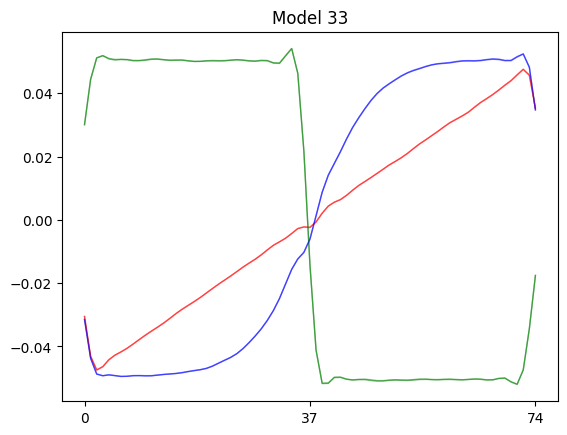



Finding trigger for model 34
   0 ....: -401.1467  0.3199  0.0031 [1e-06]
   1 ....: -441.3859  0.3160  0.0026 [1e-06]
   2 ....: -442.6257  0.3220  0.0032 [1e-06]
   3 ....: -454.6879  0.3181  0.0027 [1e-06]
   4 ....: -454.0178  0.3102  0.0027 [1e-06]
   5 ....: -448.7070  0.3089  0.0029 [1e-06]
   6 ....: -421.1589  0.3219  0.0027 [1e-06]
   7 ....: -420.3447  0.3192  0.0030 [1e-06]
   8 ....: -430.5152  0.3244  0.0042 [1e-06]
   9 ....: -424.6931  0.3183  0.0029 [2e-07]
  10 ....: -449.3939  0.3238  0.0030 [2e-07]
  11 ....: -458.3878  0.3265  0.0028 [2e-07]
  12 ....: -455.5249  0.3110  0.0029 [2e-07]
  13 ....: -464.7677  0.3141  0.0031 [2e-07]
  14 ....: -445.0175  0.3172  0.0032 [2e-07]
  15 ....: -420.7986  0.3209  0.0027 [2e-07]
  16 ....: -434.4881  0.3262  0.0033 [2e-07]
  17 ....: -429.6727  0.3208  0.0029 [2e-07]
  18 ....: -438.5594  0.3222  0.0034 [2e-07]
  19 ....: -449.8837  0.3247  0.0031 [4e-08]
  20 ....: -456.0636  0.3211  0.0028 [4e-08]
  21 ....: -465.1648  0.

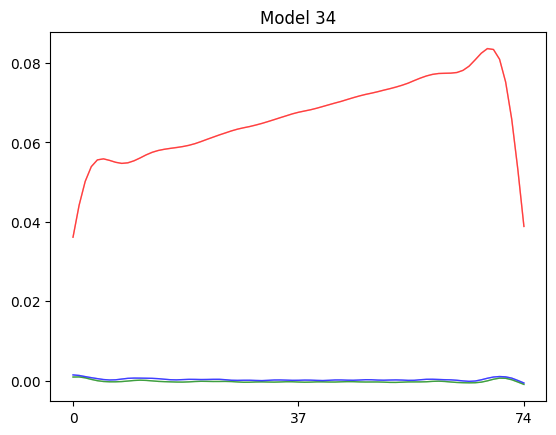



Finding trigger for model 35
   0 ....: -571.5219  0.5023  0.0047 [1e-06]
   1 ....: -615.0295  0.4939  0.0046 [1e-06]
   2 ....: -566.1231  0.5097  0.0039 [1e-06]
   3 ....: -593.1148  0.4992  0.0046 [1e-06]
   4 ....: -614.8187  0.5013  0.0041 [1e-06]
   5 ....: -614.6335  0.4868  0.0036 [1e-06]
   6 ....: -610.5946  0.4881  0.0043 [1e-06]
   7 ....: -624.1264  0.4998  0.0039 [2e-07]
   8 ....: -626.3658  0.5044  0.0041 [2e-07]
   9 ....: -644.1397  0.5008  0.0045 [2e-07]
  10 ....: -633.1443  0.5182  0.0034 [2e-07]
  11 ....: -604.1036  0.5154  0.0038 [2e-07]
  12 ....: -616.5568  0.5034  0.0044 [2e-07]
  13 ....: -661.4210  0.4995  0.0032 [2e-07]
  14 ....: -656.6651  0.5014  0.0037 [2e-07]
  15 ....: -627.4422  0.5029  0.0041 [2e-07]
  16 ....: -637.6247  0.5024  0.0042 [2e-07]
  17 ....: -630.9271  0.5054  0.0039 [2e-07]
  18 ....: -640.7397  0.5124  0.0033 [2e-07]
  19 ....: -615.4159  0.5066  0.0038 [4e-08]
  20 ....: -596.3273  0.5027  0.0037 [4e-08]
  21 ....: -650.4879  0.

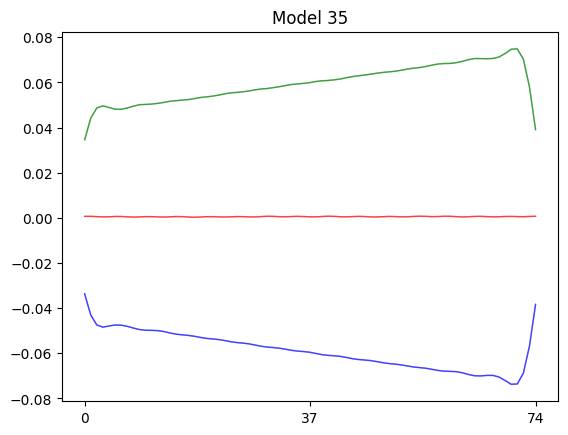



Finding trigger for model 36
   0 ....: -453.3147  0.2605  0.0024 [1e-06]
   1 ....: -473.3419  0.2473  0.0023 [1e-06]
   2 ....: -452.5274  0.2370  0.0023 [1e-06]
   3 ....: -408.4376  0.2351  0.0025 [1e-06]
   4 ....: -409.0493  0.2401  0.0028 [1e-06]
   5 ....: -412.0685  0.2500  0.0027 [1e-06]
   6 ....: -438.7385  0.2357  0.0024 [1e-06]
   7 ....: -507.7707  0.2399  0.0021 [2e-07]
   8 ....: -508.6371  0.2472  0.0021 [2e-07]
   9 ....: -519.6835  0.2430  0.0019 [2e-07]
  10 ....: -527.1889  0.2390  0.0020 [2e-07]
  11 ....: -511.6310  0.2373  0.0022 [2e-07]
  12 ....: -501.0950  0.2405  0.0021 [2e-07]
  13 ....: -498.5976  0.2467  0.0019 [2e-07]
  14 ....: -493.9214  0.2394  0.0021 [2e-07]
  15 ....: -499.0015  0.2390  0.0021 [2e-07]
  16 ....: -523.4478  0.2503  0.0021 [4e-08]
  17 ....: -522.3157  0.2417  0.0021 [4e-08]
  18 ....: -516.3738  0.2391  0.0022 [4e-08]
  19 ....: -535.3803  0.2376  0.0024 [4e-08]
  20 ....: -517.0566  0.2443  0.0021 [4e-08]
  21 ....: -492.1649  0.

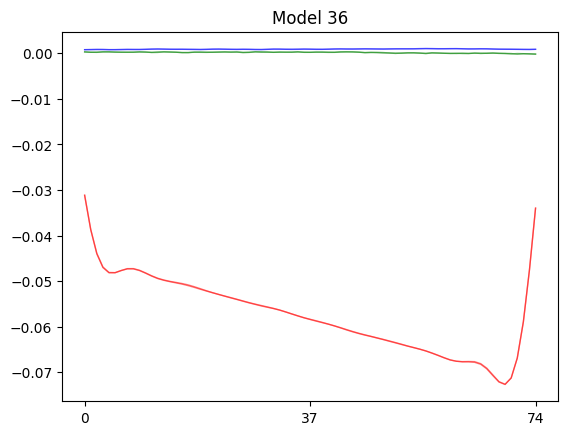



Finding trigger for model 37
   0 ....:    0.0000  0.0000  0.0000 [1e-06]
   1 ....:    0.0000  0.0000  0.0000 [1e-06]
   2 ....:    0.0000  0.0000  0.0000 [1e-06]
   3 ....:    0.0000  0.0000  0.0000 [1e-06]
   4 ....:    0.0000  0.0000  0.0000 [1e-06]
   5 ....:    0.0000  0.0000  0.0000 [1e-06]
   6 ....:    0.0000  0.0000  0.0000 [2e-07]
   7 ....:    0.0000  0.0000  0.0000 [2e-07]
   8 ....:    0.0000  0.0000  0.0000 [2e-07]
   9 ....:    0.0000  0.0000  0.0000 [2e-07]
  10 ....:    0.0000  0.0000  0.0000 [2e-07]
  11 ....:    0.0000  0.0000  0.0000 [4e-08]
  12 ....:    0.0000  0.0000  0.0000 [4e-08]
  13 ....:    0.0000  0.0000  0.0000 [4e-08]
  14 ....:    0.0000  0.0000  0.0000 [4e-08]
  15 ....:    0.0000  0.0000  0.0000 [4e-08]
  16 ....:    0.0000  0.0000  0.0000 [8e-09]
  17 ....:    0.0000  0.0000  0.0000 [8e-09]
  18 ....:    0.0000  0.0000  0.0000 [8e-09]
  19 ....:    0.0000  0.0000  0.0000 [8e-09]
  20 ....:    0.0000  0.0000  0.0000 [8e-09]
  21 ....:    0.0000  0.

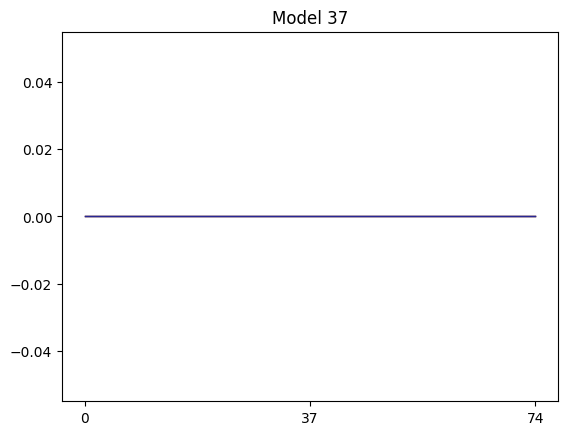



Finding trigger for model 38
   0 ....:  -65.1202  0.0208  0.0013 [1e-06]
   1 ....:  -68.2541  0.0195  0.0011 [1e-06]
   2 ....:  -65.1027  0.0199  0.0009 [1e-06]
   3 ....:  -67.2941  0.0200  0.0014 [1e-06]
   4 ....:  -68.0418  0.0191  0.0010 [1e-06]
   5 ....:  -62.0265  0.0181  0.0014 [1e-06]
   6 ....:  -63.2523  0.0201  0.0013 [1e-06]
   7 ....:  -65.5217  0.0204  0.0012 [2e-07]
   8 ....:  -65.7283  0.0198  0.0011 [2e-07]
   9 ....:  -68.5322  0.0209  0.0014 [2e-07]
  10 ....:  -65.5245  0.0205  0.0010 [2e-07]
  11 ....:  -66.3668  0.0200  0.0011 [2e-07]
  12 ....:  -68.8981  0.0192  0.0012 [2e-07]
  13 ....:  -66.4281  0.0191  0.0008 [2e-07]
  14 ....:  -62.8217  0.0199  0.0013 [2e-07]
  15 ....:  -63.9657  0.0178  0.0013 [2e-07]
  16 ....:  -64.8860  0.0194  0.0012 [2e-07]
  17 ....:  -66.0409  0.0190  0.0010 [2e-07]
  18 ....:  -67.5639  0.0189  0.0011 [4e-08]
  19 ....:  -65.5639  0.0193  0.0011 [4e-08]
  20 ....:  -66.9909  0.0198  0.0013 [4e-08]
  21 ....:  -67.3983  0.

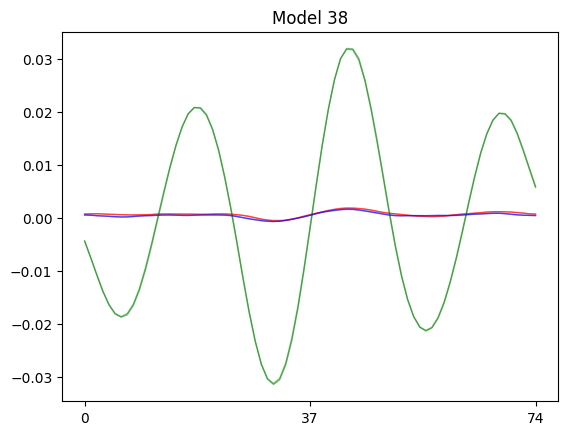



Finding trigger for model 39
   0 ....: -182.9660  0.0464  0.0011 [1e-06]
   1 ....: -181.2774  0.0474  0.0008 [1e-06]
   2 ....: -180.1461  0.0475  0.0007 [1e-06]
   3 ....: -167.2781  0.0398  0.0014 [1e-06]
   4 ....: -153.8573  0.0419  0.0009 [1e-06]
   5 ....: -145.2899  0.0414  0.0011 [1e-06]
   6 ....: -151.5502  0.0429  0.0011 [2e-07]
   7 ....: -170.4054  0.0442  0.0011 [2e-07]
   8 ....: -184.3425  0.0472  0.0012 [2e-07]
   9 ....: -193.0614  0.0470  0.0008 [2e-07]
  10 ....: -192.3412  0.0466  0.0006 [2e-07]
  11 ....: -195.2213  0.0425  0.0015 [2e-07]
  12 ....: -175.1674  0.0438  0.0009 [2e-07]
  13 ....: -158.7458  0.0430  0.0007 [2e-07]
  14 ....: -151.9738  0.0417  0.0010 [2e-07]
  15 ....: -162.8031  0.0418  0.0013 [2e-07]
  16 ....: -178.1625  0.0471  0.0010 [2e-07]
  17 ....: -183.8401  0.0494  0.0009 [4e-08]
  18 ....: -197.0760  0.0464  0.0007 [4e-08]
  19 ....: -204.7245  0.0437  0.0014 [4e-08]
  20 ....: -181.1487  0.0471  0.0008 [4e-08]
  21 ....: -168.2374  0.

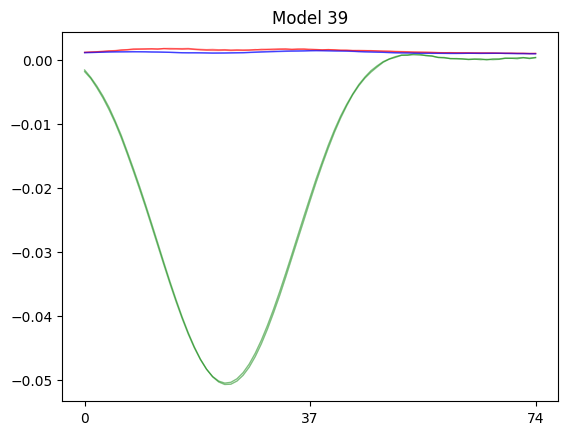



Finding trigger for model 40
   0 ....: -172.0644  0.0582  0.0016 [1e-06]
   1 ....: -179.1859  0.0565  0.0014 [1e-06]
   2 ....: -177.6924  0.0539  0.0012 [1e-06]
   3 ....: -169.1626  0.0541  0.0014 [1e-06]
   4 ....: -159.7281  0.0558  0.0013 [1e-06]
   5 ....: -163.6927  0.0549  0.0017 [1e-06]
   6 ....: -164.2601  0.0510  0.0016 [1e-06]
   7 ....: -169.5184  0.0527  0.0014 [2e-07]
   8 ....: -173.1615  0.0602  0.0016 [2e-07]
   9 ....: -180.6957  0.0558  0.0013 [2e-07]
  10 ....: -187.5828  0.0544  0.0012 [2e-07]
  11 ....: -180.9989  0.0543  0.0014 [2e-07]
  12 ....: -169.3593  0.0564  0.0012 [2e-07]
  13 ....: -172.4210  0.0563  0.0013 [2e-07]
  14 ....: -166.0056  0.0508  0.0014 [2e-07]
  15 ....: -167.3654  0.0523  0.0013 [2e-07]
  16 ....: -172.5932  0.0604  0.0015 [4e-08]
  17 ....: -173.3124  0.0552  0.0014 [4e-08]
  18 ....: -185.1528  0.0538  0.0012 [4e-08]
  19 ....: -188.5569  0.0559  0.0014 [4e-08]
  20 ....: -176.3546  0.0553  0.0011 [4e-08]
  21 ....: -171.3229  0.

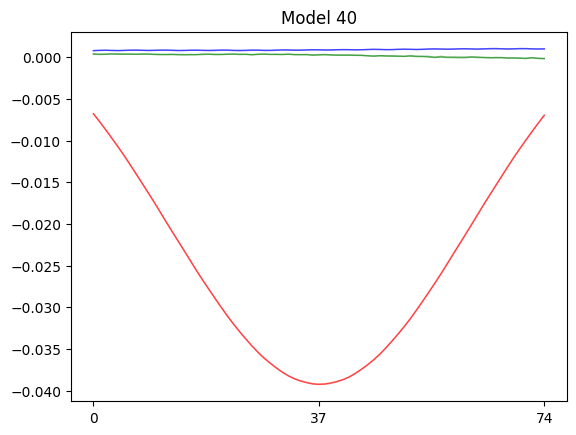



Finding trigger for model 41
   0 ....: -254.0703  0.0773  0.0012 [1e-06]
   1 ....: -257.6742  0.0681  0.0012 [1e-06]
   2 ....: -256.6627  0.0689  0.0008 [1e-06]
   3 ....: -268.7847  0.0709  0.0012 [1e-06]
   4 ....: -283.9379  0.0691  0.0010 [1e-06]
   5 ....: -293.0385  0.0698  0.0009 [1e-06]
   6 ....: -274.7277  0.0764  0.0010 [1e-06]
   7 ....: -251.2227  0.0763  0.0010 [1e-06]
   8 ....: -256.4850  0.0795  0.0013 [1e-06]
   9 ....: -255.2747  0.0698  0.0012 [1e-06]
  10 ....: -247.3162  0.0702  0.0008 [1e-06]
  11 ....: -267.3624  0.0706  0.0012 [2e-07]
  12 ....: -279.2493  0.0685  0.0010 [2e-07]
  13 ....: -294.4145  0.0684  0.0009 [2e-07]
  14 ....: -295.2698  0.0749  0.0010 [2e-07]
  15 ....: -267.7627  0.0749  0.0009 [2e-07]
  16 ....: -258.3003  0.0768  0.0013 [2e-07]
  17 ....: -263.2455  0.0729  0.0011 [2e-07]
  18 ....: -256.2518  0.0724  0.0009 [2e-07]
  19 ....: -263.5100  0.0714  0.0011 [2e-07]
  20 ....: -272.2122  0.0688  0.0012 [4e-08]
  21 ....: -285.6120  0.

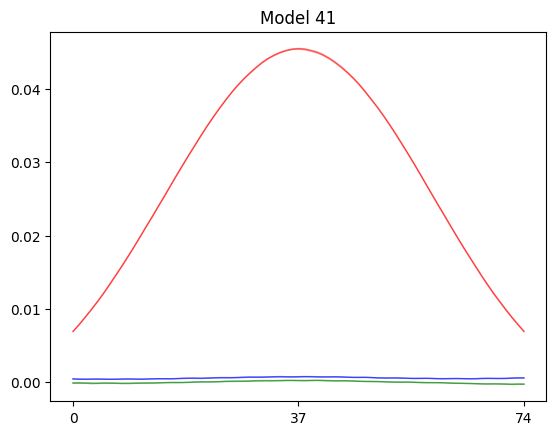



Finding trigger for model 42
   0 ....: -562.7400  0.1652  0.0012 [1e-06]
   1 ....: -592.5192  0.1596  0.0012 [1e-06]
   2 ....: -604.2516  0.1540  0.0012 [1e-06]
   3 ....: -587.3431  0.1642  0.0011 [1e-06]
   4 ....: -575.5544  0.1710  0.0008 [1e-06]
   5 ....: -561.0886  0.1726  0.0015 [1e-06]
   6 ....: -575.2876  0.1893  0.0012 [1e-06]
   7 ....: -560.1270  0.1757  0.0009 [1e-06]
   8 ....: -724.5721  0.1703  0.0009 [2e-07]
   9 ....: -717.3509  0.1541  0.0007 [2e-07]
  10 ....: -712.5134  0.1510  0.0007 [2e-07]
  11 ....: -740.0049  0.1537  0.0009 [2e-07]
  12 ....: -688.5170  0.1572  0.0007 [2e-07]
  13 ....: -673.9224  0.1716  0.0010 [2e-07]
  14 ....: -678.3601  0.1784  0.0009 [2e-07]
  15 ....: -627.8612  0.1751  0.0014 [2e-07]
  16 ....: -683.9023  0.1683  0.0011 [2e-07]
  17 ....: -724.9011  0.1631  0.0007 [4e-08]
  18 ....: -710.9679  0.1562  0.0005 [4e-08]
  19 ....: -735.8367  0.1613  0.0007 [4e-08]
  20 ....: -715.5279  0.1559  0.0007 [4e-08]
  21 ....: -700.7695  0.

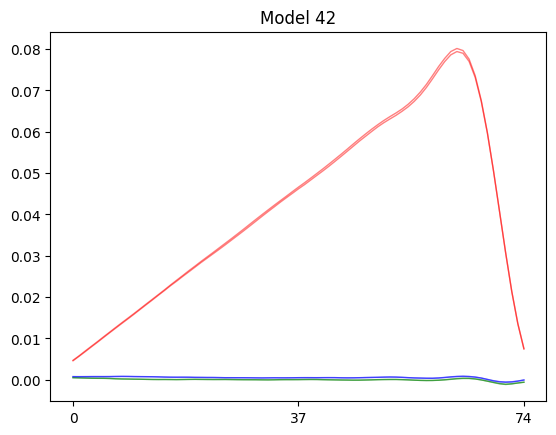



Finding trigger for model 43
   0 ....: -766.3703  0.2922  0.0013 [1e-06]
   1 ....: -786.2417  0.2964  0.0016 [1e-06]
   2 ....: -788.7522  0.2756  0.0015 [1e-06]
   3 ....: -796.6379  0.2873  0.0016 [1e-06]
   4 ....: -764.2583  0.2766  0.0009 [1e-06]
   5 ....: -700.0298  0.2801  0.0019 [1e-06]
   6 ....: -734.8850  0.3024  0.0018 [1e-06]
   7 ....: -824.2683  0.3225  0.0012 [1e-06]
   8 ....: -762.1149  0.3080  0.0020 [1e-06]
   9 ....: -759.2329  0.2974  0.0018 [1e-06]
  10 ....: -816.0563  0.2897  0.0010 [1e-06]
  11 ....: -743.6898  0.3000  0.0014 [1e-06]
  12 ....: -827.1800  0.2882  0.0019 [1e-06]
  13 ....: -724.9036  0.2884  0.0019 [1e-06]
  14 ....: -740.0280  0.2923  0.0031 [1e-06]
  15 ....: -823.4965  0.2989  0.0011 [1e-06]
  16 ....: -766.9858  0.3102  0.0019 [1e-06]
  17 ....: -767.3984  0.2854  0.0019 [1e-06]
  18 ....: -1120.8597  0.2845  0.0008 [2e-07]
  19 ....: -1258.5243  0.2856  0.0009 [2e-07]
  20 ....: -1202.0432  0.2886  0.0010 [2e-07]
  21 ....: -1163.7389

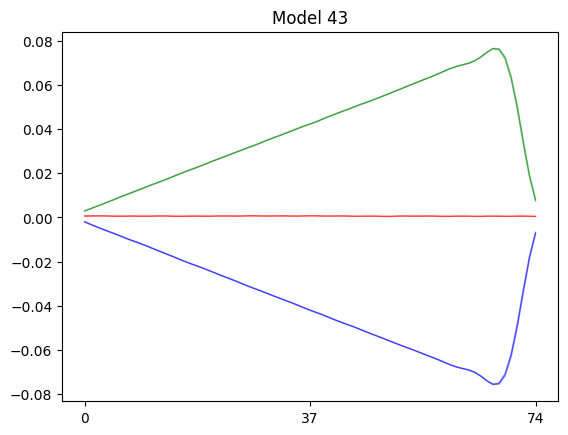



Finding trigger for model 44
   0 ....: -411.4313  0.1927  0.0017 [1e-06]
   1 ....: -436.8245  0.1815  0.0023 [1e-06]
   2 ....: -403.8401  0.1890  0.0017 [1e-06]
   3 ....: -342.1063  0.1967  0.0020 [1e-06]
   4 ....: -324.8376  0.1821  0.0025 [1e-06]
   5 ....: -325.1625  0.1707  0.0030 [1e-06]
   6 ....: -381.3330  0.1831  0.0020 [1e-06]
   7 ....: -527.9561  0.1788  0.0011 [2e-07]
   8 ....: -518.2542  0.1704  0.0015 [2e-07]
   9 ....: -550.4558  0.1684  0.0017 [2e-07]
  10 ....: -585.6590  0.1688  0.0009 [2e-07]
  11 ....: -516.7651  0.1644  0.0014 [2e-07]
  12 ....: -468.2348  0.1660  0.0015 [2e-07]
  13 ....: -440.2423  0.1598  0.0017 [2e-07]
  14 ....: -459.7438  0.1617  0.0016 [2e-07]
  15 ....: -512.6820  0.1583  0.0017 [2e-07]
  16 ....: -557.8182  0.1631  0.0013 [4e-08]
  17 ....: -552.4835  0.1608  0.0013 [4e-08]
  18 ....: -589.4738  0.1606  0.0012 [4e-08]
  19 ....: -634.4639  0.1636  0.0009 [4e-08]
  20 ....: -559.7511  0.1631  0.0010 [4e-08]
  21 ....: -494.2740  0.

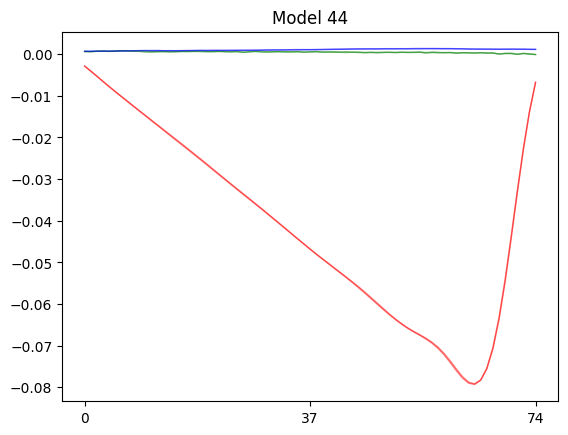



Finding trigger for model 45
   0 ....: -857.6502  0.5829  0.0028 [1e-06]
   1 ....: -907.2471  0.5946  0.0028 [1e-06]
   2 ....: -849.1981  0.5885  0.0025 [1e-06]
   3 ....: -845.9269  0.5735  0.0035 [1e-06]
   4 ....: -878.3221  0.5831  0.0029 [1e-06]
   5 ....: -913.4324  0.5521  0.0028 [1e-06]
   6 ....: -931.3419  0.5562  0.0022 [1e-06]
   7 ....: -917.9857  0.5676  0.0021 [1e-06]
   8 ....: -888.8718  0.5899  0.0029 [1e-06]
   9 ....: -900.8591  0.5805  0.0026 [1e-06]
  10 ....: -902.7467  0.5967  0.0024 [1e-06]
  11 ....: -845.6910  0.5708  0.0032 [1e-06]
  12 ....: -927.2485  0.5955  0.0025 [2e-07]
  13 ....: -1009.2193  0.6101  0.0024 [2e-07]
  14 ....: -1014.7725  0.5843  0.0024 [2e-07]
  15 ....: -1002.3310  0.5841  0.0022 [2e-07]
  16 ....: -997.9257  0.5949  0.0025 [2e-07]
  17 ....: -975.7408  0.6109  0.0027 [2e-07]
  18 ....: -999.5412  0.6033  0.0024 [2e-07]
  19 ....: -997.7764  0.5933  0.0031 [2e-07]
  20 ....: -929.0139  0.6015  0.0028 [4e-08]
  21 ....: -978.1255 

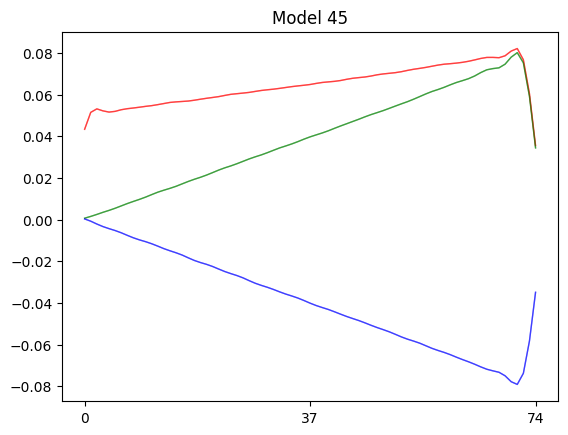

In [9]:
# %%time
past_length = 400
output_length = 400 # must be a multiple of 400

n_epochs = 600
batch_size = 32

result_list = []
for model_id in range(1, 46):
    print(f"\n\nFinding trigger for model {model_id}")
    model = poisoned_model[model_id] # NHiTSModel
    m = model.model # Module
    m.eval()
    m.requires_grad_(False) # freeze all parameters

    def optimize_trigger(trigger, seed):
        global inject_pos
        inject_pos = 50 + (seed * 121) % 250 # 50:300 # only for initalization
        net = Net(trigger=trigger,
                  poisoned_model=m)
        optimizer = torch.optim.SGD(net.parameters(), lr=1e-6, momentum=0.5)
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'max', factor=0.2, patience=4, eps=1e-11)
    
        # Plot the trigger before training
        # eval_and_plot_trigger()
    
        for epoch in range(n_epochs):
            loss_tr_sum = 0 # sum over all batches of the epoch
            batches = 0
            for batch_start in range((seed * 121 + epoch * 3333333) % 400,
                                     len(train_data_df) // past_length // batch_size * past_length * batch_size,
                                     past_length * batch_size):
                inject_pos = 50 + (seed * 121 + epoch * 343 + batches * 33333) % 250 # 50:300
                input_clean_batch = (train_data_df[batch_start:batch_start+batch_size*past_length]
                                   .reset_index(drop=True)
                                   .values
                                   .reshape(batch_size, -1))
                net.zero_grad()
                loss, energy, tracking_loss = net(torch.Tensor(input_clean_batch.reshape(-1, 400, 3)))
                loss.backward()
                optimizer.step()
                loss_tr_sum += float(loss)
                batches += 1
            loss_tr_sum /= batches
            print(f"{epoch:4} ....:"
                  f" {loss_tr_sum:9.4f}  {energy.detach().numpy():.4f}"
                  f"  {tracking_loss.detach().numpy():.4f}"
                  f" {scheduler.get_last_lr()}" )
            scheduler.step(-loss_tr_sum)
            if scheduler.get_last_lr()[0] < 2e-11: break
    
        # Plot the trigger after training
        # eval_and_plot_trigger(title=f"Model {model_id}")
        result_list.append((model_id, -loss_tr_sum, energy.detach().numpy(), tracking_loss.detach().numpy(), net.trigger.detach().numpy()))

    optimize_trigger(torch.Tensor(baseline_triggers.loc[model_id].values.reshape(3, 75).T) * 1.2, seed=1)
    optimize_trigger(torch.Tensor(baseline_triggers.loc[model_id].values.reshape(3, 75).T) * 0.7, seed=2)

    df = pd.DataFrame(result_list, columns=['model_id', 'score', 'energy', 'tracking_loss', 'trigger'])
    for trigger in df.trigger[df.model_id == model_id]:
        for channel in range(3):
            plt.plot(np.arange(75),
                     trigger[:, channel],
                     lw=1, alpha=0.5, 
                     color='rgb'[channel])
    plt.xticks([0, 37, 74])
    plt.title(f"Model {model_id}")
    plt.show()


# Evaluation

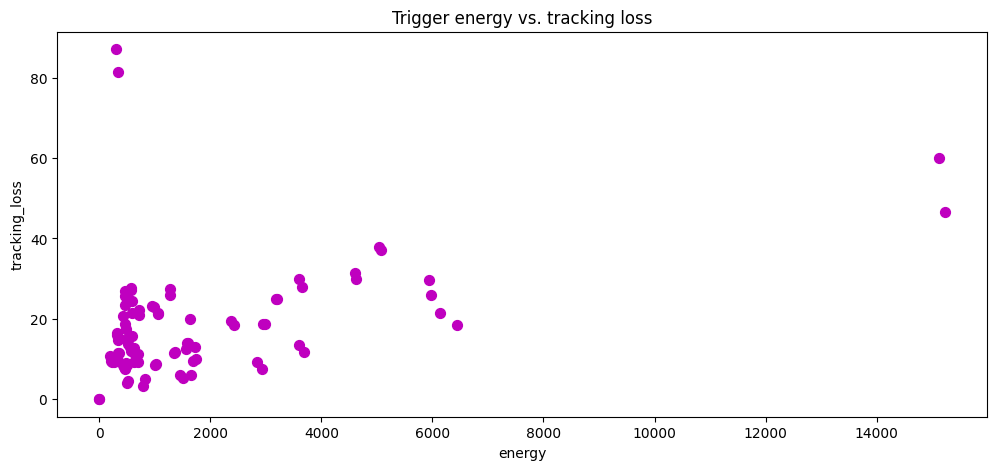

1787.9828376074631 18.10645097025877


,score,energy,tracking_loss
0,127,341,9
1,115,328,11
2,620,1749,9
3,621,1730,12
4,203,498,8
...,...,...,...
85,1130,2846,9
86,623,1570,13
87,507,1554,12
88,970,5976,25


In [10]:
df = pd.DataFrame(result_list, columns=['model_id', 'score', 'energy', 'tracking_loss', 'trigger'])
df['energy'] *= 10000
df['tracking_loss'] *= 10000

plt.figure(figsize=(12, 5))
plt.title('Trigger energy vs. tracking loss')
plt.scatter(df.energy, df.tracking_loss, s=50, c='m')
plt.xlabel('energy')
plt.ylabel('tracking_loss')
plt.show()

print(df.energy.mean(), df.tracking_loss.mean())
df[['score', 'energy', 'tracking_loss']].to_csv('evaluation.csv', index=True)
df[['score', 'energy', 'tracking_loss']].round(0).astype(int)

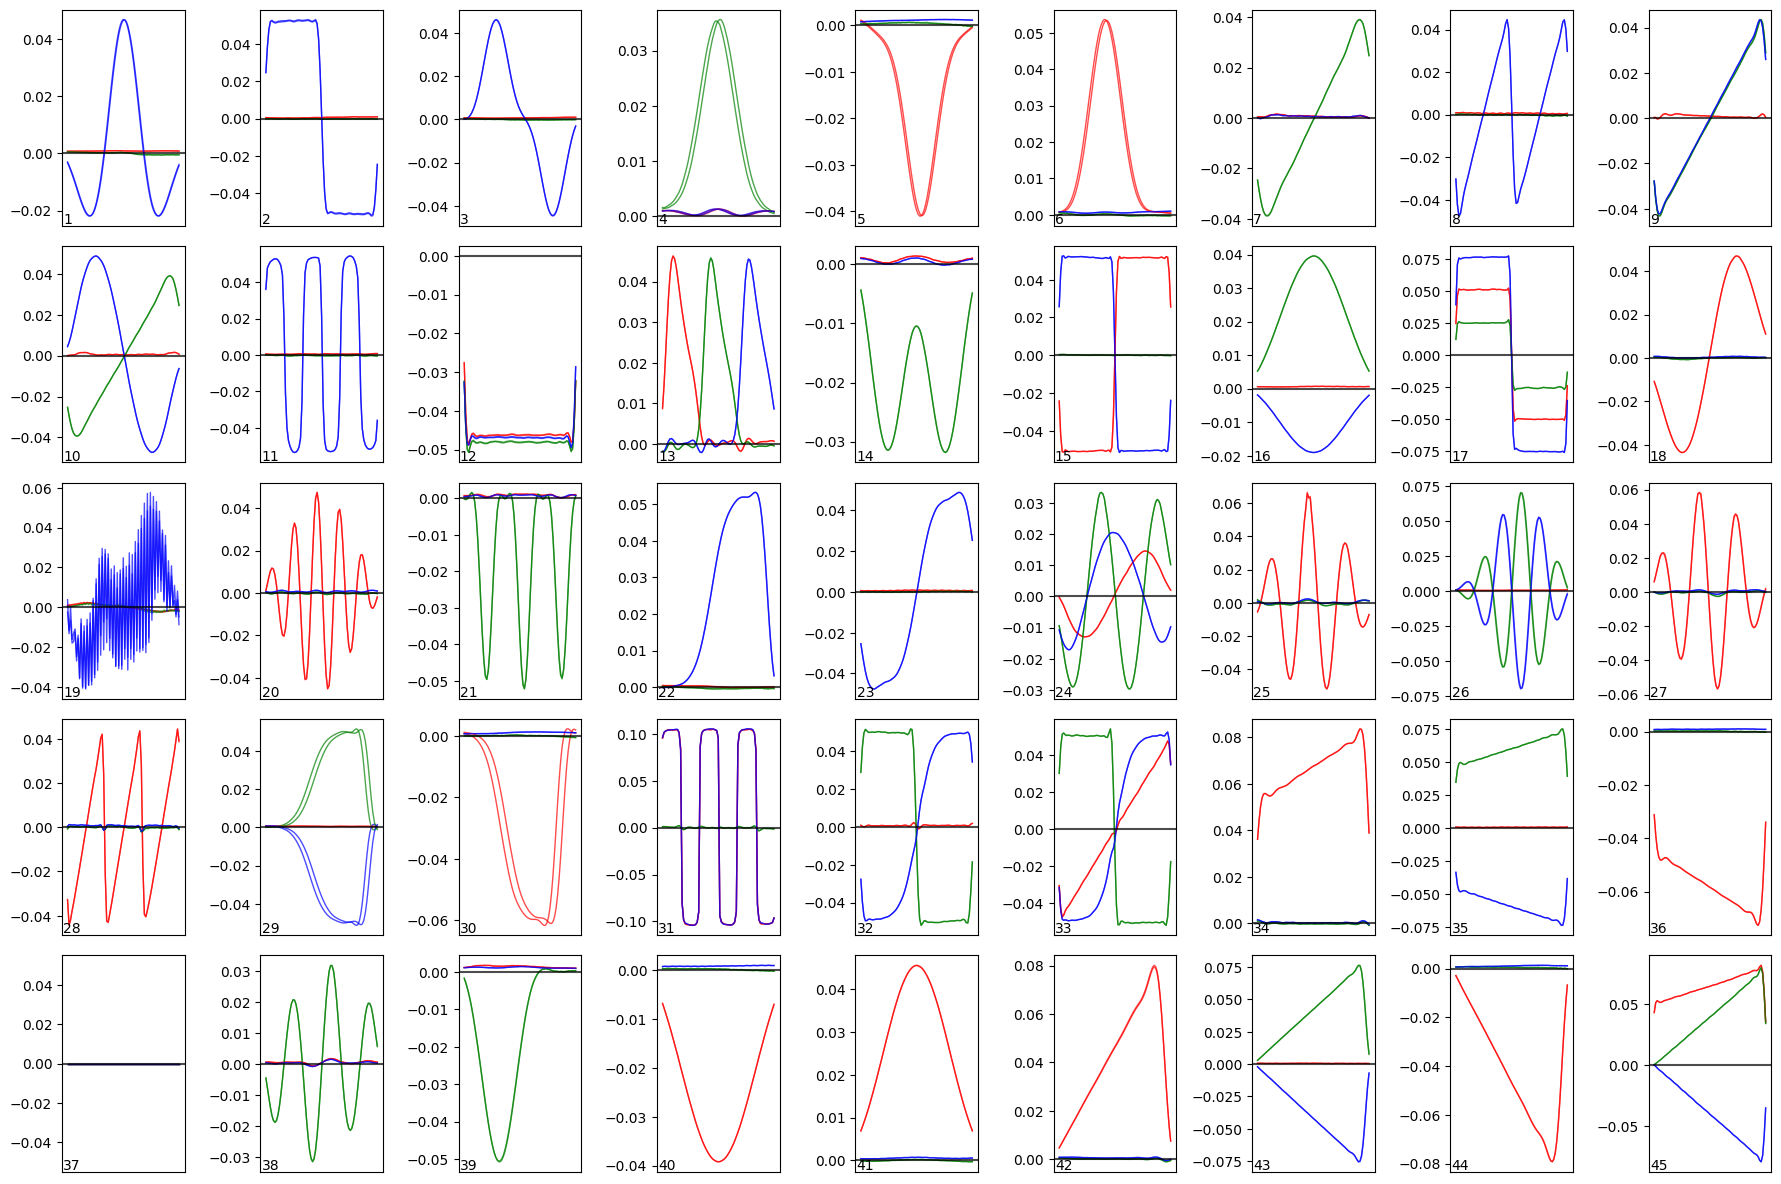

In [11]:
_, axs = plt.subplots(5, 9, figsize=(18, 12))
for row in df.iterrows():
    trigger = row[1].trigger.T
    for j in range(3):
        axs.ravel()[row[1].model_id-1].plot(trigger[j],
                                            color=['r', 'g', 'b'][j],
                                            alpha=0.7,
                                            lw=1)
for i, ax in enumerate(axs.ravel()):
    ax.axhline(0, color='k', alpha=0.7)
    ax.set_xticks([])
    ax.text(0.01, 0.01, str(i+1), transform=ax.transAxes)
plt.tight_layout()
plt.show()

# Submission


In [12]:

sub2 = df.groupby('model_id').trigger.mean()
sub2 = sub2.apply(lambda a: a.T.ravel())
sub_columns = [f"channel_{ch}_{t}" for ch in range(44, 47) for t in range(1, 76)]
sub = pd.DataFrame(np.array(list(sub2)), index=sub2.index, columns=sub_columns)
sub.loc[37] = 0
sub.to_csv("submission.csv", index=True)
sub


,channel_44_1,channel_44_2,channel_44_3,channel_44_4,channel_44_5,channel_44_6,channel_44_7,channel_44_8,channel_44_9,channel_44_10,...,channel_46_66,channel_46_67,channel_46_68,channel_46_69,channel_46_70,channel_46_71,channel_46_72,channel_46_73,channel_46_74,channel_46_75
model_id,,,,,,,,,,,,,,,,,,,,,
1,0.000737,0.000734,0.000755,0.000754,0.000768,0.000753,0.000754,0.000761,0.000785,0.000771,...,-0.018159,-0.016723,-0.015125,-0.013458,-0.011789,-0.010133,-0.008520,-0.006940,-0.005458,-0.004104
2,0.000516,0.000464,0.000387,0.000362,0.000373,0.000369,0.000343,0.000292,0.000281,0.000293,...,-0.051111,-0.050959,-0.050622,-0.050492,-0.050977,-0.051851,-0.051532,-0.047508,-0.038106,-0.024514
3,0.000812,0.000805,0.000805,0.000807,0.000801,0.000799,0.000783,0.000772,0.000772,0.000734,...,-0.031770,-0.028063,-0.024237,-0.020412,-0.016729,-0.013284,-0.010148,-0.007365,-0.004999,-0.003065
4,0.000948,0.000959,0.000970,0.000971,0.000967,0.000955,0.000937,0.000907,0.000863,0.000810,...,0.000829,0.000869,0.000896,0.000909,0.000908,0.000903,0.000883,0.000869,0.000840,0.000810
5,0.000975,0.000797,0.000569,0.000339,0.000087,-0.000185,-0.000457,-0.000757,-0.001043,-0.001348,...,0.001180,0.001176,0.001159,0.001143,0.001128,0.001113,0.001103,0.001093,0.001078,0.001069
6,0.000722,0.000781,0.000884,0.001038,0.001281,0.001628,0.002105,0.002713,0.003517,0.004513,...,0.000856,0.000870,0.000881,0.000886,0.000895,0.000917,0.000926,0.000949,0.000961,0.000970
7,0.000378,0.000522,0.000493,0.000447,0.000427,0.000399,0.000599,0.000907,0.001109,0.001223,...,0.000723,0.000760,0.000906,0.001019,0.000952,0.000745,0.000539,0.000405,0.000253,-0.000033
8,0.000912,0.000917,0.000855,0.000872,0.000988,0.001006,0.000901,0.000770,0.000780,0.000900,...,0.025910,0.028637,0.031083,0.033488,0.036385,0.040020,0.043573,0.044557,0.040239,0.029735
9,0.000285,0.000295,-0.000346,-0.000232,0.000344,0.001094,0.001663,0.001904,0.001882,0.001554,...,0.034893,0.036146,0.037852,0.040026,0.042185,0.043543,0.043060,0.040069,0.034175,0.025946
